# __Group Assignment - Predicting Airbnb Listing Prices in Brisbane, Australia__

---

**Kaggle Competition Deadline:** Friday, 5 June 2026 at 3:00 PM (Week 13)  
**Assignment Due Date (iLearn):** Friday, 5 June 2026 at 11:59 PM (Week 13)  
**Total Marks:** 30  

**Overview**  
In this group assignment, you will form a team of three students and participate in a forecasting competition on Kaggle.

---
### General Instructions

- Each team member must create a Kaggle account and join the competition using the link:  
  https://www.kaggle.com/t/554f205a43a94920943d5227ae9dcbdb  

- Form a team of three students:  
  Choose a team leader who will create the team and invite the other members  
  The team name must begin with the unit code  

- All team members are expected to contribute to all tasks.  
  Each member must take primary responsibility for one of the three tasks.

- Your predictions must be generated using models developed in this assignment.  
  **A mark of zero will be awarded if your submitted forecasts cannot be reproduced from your code.**

- All results must be clearly presented and directly verifiable from your outputs and explanations.

- All written answers must be written in clear and complete sentences, supported by relevant tables, summary statistics, and visualisations where appropriate.  


<hr style="width:20%;margin-left:0;">

### Marks

- **Total Marks:** 30 (across 3 tasks)

- **Individual Mark Allocation:**  
  Each student’s mark is calculated as:   
  **0.5 × overall group assignment mark (%) + 0.5 × individual task mark (%)**,   
  with the combined percentage then converted to a mark out of 30.


<hr style="width:20%;margin-left:0;">

### Assignment Submission

1. **Kaggle Submission:**  
   - Submit your team’s forecasts on Kaggle to be ranked on the leaderboard  
2. **iLearn Submission (team leader only):**  
   - Submit the assignment as a Jupyter notebook, renamed to your **Kaggle team name**  
   - The notebook must include:
     - Names and student ID numbers of all team members  
     - Your Kaggle team name  
   - Submit **one 15-minute video presentation** of your work  
     - A penalty of **5 marks will be deducted per task** if a video presentation is not provided  

---
---

### <span style="background-color: yellow;">Fill out the following information

- Team Name on Kaggle: `(insert here)`
- Team Leader and Team Member 1: `(insert here)`
- Team Member 2: `(insert here)`
- Team Member 3: Mitali Bokil

---
---

## Task 1: Problem Description and Exploratory Data Analysis (EDA)  

**Total Marks: 10**

- Based on the Competition Overview, datasets, and additional information provided on Kaggle, along with insights gained from your own research (including relevant academic sources such as Google Scholar), answer the following questions.  
- Do not discuss any predictive models in this task.


---

Student in charge of this task: `(Bindu Sangroula)`


<hr style="width:25%;margin-left:0;">    

#### 1. Forecasting Problem (2 marks)  
In approximately **300 words**, explain what we are trying to predict and how this problem can be applied in a real-world context.  
Discuss who may benefit from these predictions and how they might use them.


---- Add your written answer here ------
The objective of this predictive analytics project is to forecast Airbnb listing prices in Brisbane, Australia using information related to each property. The dataset includes variables associated with property characteristics, host information, location, availability, and customer reviews. Examples of these variables include property type, room type, number of bedrooms and bathrooms, accommodation capacity, neighbourhood location, review scores, and availability throughout the year. By analysing these factors, the project aims to estimate the expected price of Airbnb listings and identify the main features that influence accommodation pricing.

The project uses two separate datasets: a training dataset and a testing dataset. The training dataset contains both predictor variables and the known target variable, which is price, while the testing dataset contains only predictor variables with unknown prices. Since the task involves predicting a continuous numerical value from labelled historical data, it can be classified as a supervised regression problem.

This forecasting problem has strong real-world applications within the hospitality and tourism industry. Airbnb hosts and property managers can use pricing predictions to determine competitive and profitable listing prices for their properties. Appropriate pricing is important because prices that are too high may reduce bookings, while prices that are too low may reduce potential revenue. Predictive analytics can help hosts better understand how factors such as property size, room type, location, and customer reviews affect accommodation prices.

Travellers and guests may also benefit from these predictions by comparing accommodation options and identifying properties that offer better value for money. In addition, accommodation platforms such as Airbnb can use pricing insights to improve customer recommendations, market analysis, and overall user experience. Overall, this project demonstrates how predictive analytics can support data-driven decision-making in real-world accommodation and tourism markets.

<hr style="width:25%;margin-left:0;">   

#### 2. Evaluation Criteria (2 marks)  
Describe the evaluation metric used in this competition to assess forecasting performance.  
Provide the equation and discuss its advantages and potential limitations.

---- Add your written answer here ------
The evaluation metric used in this competition is Mean Absolute Percentage Error (MAPE). This metric measures the average percentage difference between the actual Airbnb listing prices and the predicted prices generated by the forecasting model. The objective of the competition is to minimise the MAPE value, as lower values indicate more accurate predictions.
Equation for MAPE:
The equation for MAPE is:

$$
MAPE = \frac{100}{n}\sum_{t=1}^{n}\left|\frac{A_t - F_t}{A_t}\right|
$$

where:

- \(A_t\) represents the actual value
- \(F_t\) represents the forecasted or predicted value
- \(n\) represents the total number of observations


MAPE evaluates forecasting accuracy by calculating the absolute percentage error for each prediction and then averaging all errors. Because the error is expressed as a percentage, the metric is easy to interpret, understand, and compare across different models. For example, a MAPE value of 10% means that the model’s predictions are, on average, 10% away from the actual values and 10% predection error.

One major advantage of MAPE is its simplicity and interpretability. It allows analysts and business users to easily understand forecasting performance without requiring advanced statistical knowledge. In the context of Airbnb pricing, MAPE is useful because it measures prediction accuracy relative to the actual property price, making it easier to evaluate practical business performance.

However, MAPE also has several limitations. One important limitation is that MAPE is undefined when actual values are zero because division by zero cannot be performed. Although Airbnb prices in this dataset are positive, this remains an important theoretical limitation of the metric.

In addition, MAPE tends to place a heavier relative penalty on prediction errors for lower-priced listings. Small dollar errors on inexpensive properties may produce large percentage errors, while large dollar errors on expensive luxury properties may appear relatively smaller. As a result, MAPE may not fully reflect the true financial impact of prediction errors, especially in datasets containing skewed prices and high-value outliers.

<hr style="width:25%;margin-left:0;">      

#### 3. Missing Values (2 marks)  
Identify and report the number of missing values in the dataset using appropriate summaries.  
Clearly interpret your findings for both the training and test datasets.

In [1]:
# Add your code here

import pandas as pd
import numpy as np

# Load datasets
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Display dataset shapes
print("Training Dataset Shape:", train.shape)
print("Test Dataset Shape:", test.shape)

Training Dataset Shape: (3735, 65)
Test Dataset Shape: (1601, 64)


In [2]:
# Function to create missing value summary
def missing_value_summary(data):
    summary = pd.DataFrame({
        "Missing Values": data.isnull().sum(),
        "Percentage (%)": (data.isnull().sum() / len(data)) * 100
    })

    # Keep only columns with missing values
    summary = summary[summary["Missing Values"] > 0]

    # Sort from highest to lowest missing values
    summary = summary.sort_values(by="Missing Values", ascending=False)

    # Round percentage for cleaner output
    summary["Percentage (%)"] = summary["Percentage (%)"].round(2)

    return summary

In [3]:
# Missing value summary for training dataset
train_missing_summary = missing_value_summary(train)

print("Training Dataset Missing Value Summary")
display(train_missing_summary)

Training Dataset Missing Value Summary


,Missing Values,Percentage (%)
host_neighbourhood,3599,96.36
neighborhood_overview,1981,53.04
host_about,1492,39.95
host_location,818,21.90
reviews_per_month,437,11.70
review_scores_rating,437,11.70
review_scores_accuracy,437,11.70
review_scores_cleanliness,437,11.70
review_scores_checkin,437,11.70
review_scores_communication,437,11.70


In [4]:
# Missing value summary for test dataset
test_missing_summary = missing_value_summary(test)

print("Test Dataset Missing Value Summary")
display(test_missing_summary)

Test Dataset Missing Value Summary


,Missing Values,Percentage (%)
host_neighbourhood,1536,95.94
neighborhood_overview,847,52.90
host_about,618,38.60
host_location,337,21.05
reviews_per_month,183,11.43
review_scores_communication,183,11.43
last_review,183,11.43
first_review,183,11.43
review_scores_cleanliness,183,11.43
review_scores_checkin,183,11.43


In [5]:
# show only top 15 missing columns for easier reporting
print("Top 15 Missing Variables in Training Dataset")
display(train_missing_summary.head(15))

print("Top 15 Missing Variables in Test Dataset")
display(test_missing_summary.head(15))

Top 15 Missing Variables in Training Dataset


,Missing Values,Percentage (%)
host_neighbourhood,3599,96.36
neighborhood_overview,1981,53.04
host_about,1492,39.95
host_location,818,21.90
reviews_per_month,437,11.70
review_scores_rating,437,11.70
review_scores_accuracy,437,11.70
review_scores_cleanliness,437,11.70
review_scores_checkin,437,11.70
review_scores_communication,437,11.70


Top 15 Missing Variables in Test Dataset


,Missing Values,Percentage (%)
host_neighbourhood,1536,95.94
neighborhood_overview,847,52.90
host_about,618,38.60
host_location,337,21.05
reviews_per_month,183,11.43
review_scores_communication,183,11.43
last_review,183,11.43
first_review,183,11.43
review_scores_cleanliness,183,11.43
review_scores_checkin,183,11.43


---- Add your written answer here ------

The dataset inspection shows that the training dataset contains 3,735 observations and 65 variables, while the test dataset contains 1,601 observations and 64 variables. The difference of one variable is expected because the training dataset includes the target variable, price, whereas the test dataset does not contain target values and is used for forecasting predictions.

The missing value analysis identified several variables with incomplete data in both datasets. The variable host_neighbourhood contains the highest level of missingness, with approximately 96% missing values in both the training and testing datasets. Similarly, neighborhood_overview contains about 53% missing values, while host_about contains around 40% missing values in the training dataset and approximately 39% missing values in the testing dataset. These variables are mostly text-based attributes and may provide limited predictive usefulness unless advanced preprocessing or text analysis techniques are applied.

Moderate levels of missing data were identified in review-related variables such as review_scores_rating, review_scores_accuracy, review_scores_cleanliness, review_scores_checkin, review_scores_communication, review_scores_location, review_scores_value, first_review, last_review, and reviews_per_month. These variables contain approximately 11% missing values in both datasets. This pattern is likely because some Airbnb listings are new or have not yet received customer reviews.

Host-related variables including host_response_rate, host_response_time, and host_acceptance_rate also contain moderate levels of missingness. However, several important numerical and property-related variables such as bathrooms, beds, and bedrooms contain only a small proportion of missing values, indicating that most property information is relatively complete.

Overall, both the training and testing datasets demonstrate very similar missing-value patterns. This consistency is beneficial for predictive analytics because preprocessing techniques applied to the training dataset can later be implemented consistently on the testing dataset before forecasting.

<hr style="width:25%;margin-left:0;">      

#### 4. Univariate Data Analysis (2 marks)  
Present and discuss key *univariate* characteristics of the training data.  
Use appropriate summary statistics and visualisations (e.g. histograms for numerical variables, bar charts for categorical variables) to support your analysis.  
For example you may consider variables such as price, room type, number of listings per host, availability, or geographical location.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load training dataset
train = pd.read_csv("train.csv")

In [7]:
# Remove dollar sign and commas, then convert to float
train['price'] = train['price'].replace('[\$,]', '', regex=True).astype(float)

<>:2: SyntaxWarning: invalid escape sequence '\$'
<>:2: SyntaxWarning: invalid escape sequence '\$'
/var/folders/nt/667gntys12b_jd3zbhkyhsl40000gn/T/ipykernel_97568/1890610718.py:2: SyntaxWarning: invalid escape sequence '\$'
  train['price'] = train['price'].replace('[\$,]', '', regex=True).astype(float)


In [8]:
# Important numerical variables for univariate analysis
selected_numerical = [
    'price',
    'accommodates',
    'bedrooms',
    'bathrooms',
    'availability_365',
    'number_of_reviews',
    'host_listings_count'
]

In [9]:
# Missing values for selected numerical variables
train[selected_numerical].isnull().sum()

price                  0
accommodates           0
bedrooms               2
bathrooms              5
availability_365       0
number_of_reviews      0
host_listings_count    2
dtype: int64

In [10]:
# Summary statistics
train[selected_numerical].describe()

,price,accommodates,bedrooms,bathrooms,availability_365,number_of_reviews,host_listings_count
count,3735.000000,3735.000000,3733.000000,3730.000000,3735.000000,3735.000000,3733.000000
mean,230.082463,3.702811,1.758639,1.424129,198.401339,50.595448,50.068042
std,194.648174,2.308905,1.110403,0.705594,119.506895,90.078291,111.875072
min,36.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,129.000000,2.000000,1.000000,1.000000,83.000000,4.000000,1.000000
50%,193.000000,3.000000,1.000000,1.000000,192.000000,18.000000,5.000000
75%,267.000000,4.000000,2.000000,2.000000,322.000000,56.000000,32.000000
max,5000.000000,16.000000,9.000000,9.000000,365.000000,1130.000000,702.000000


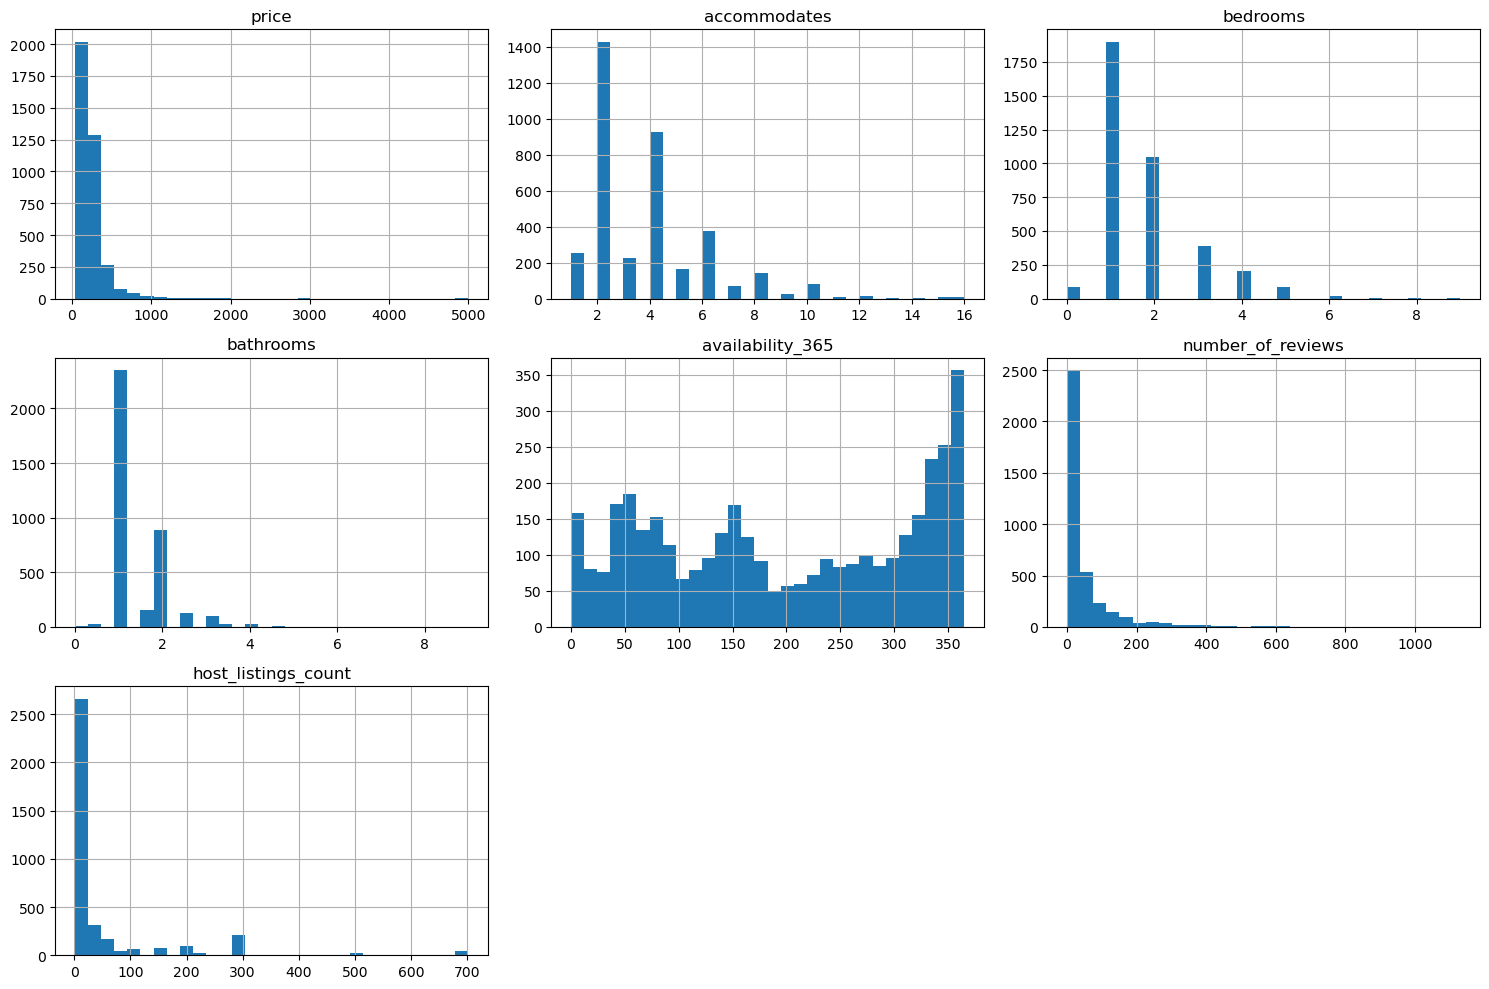

In [11]:


# Histograms for numerical variables
train[selected_numerical].hist(
    figsize=(15,10),
    bins=30
)

plt.tight_layout()
plt.show()

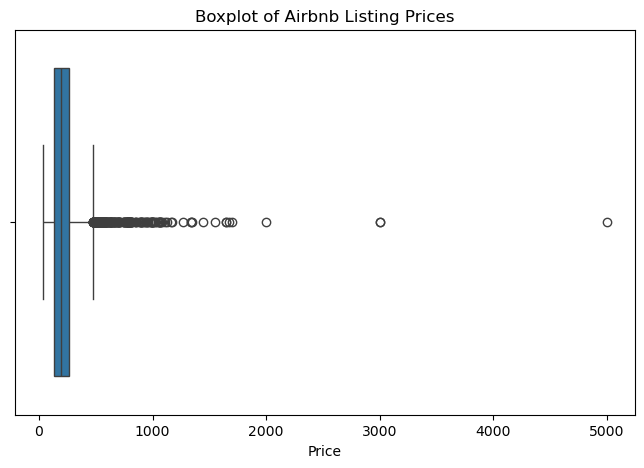

In [12]:
# Boxplot for price
plt.figure(figsize=(8,5))

sns.boxplot(x=train['price'])

plt.title('Boxplot of Airbnb Listing Prices')
plt.xlabel('Price')

plt.show()

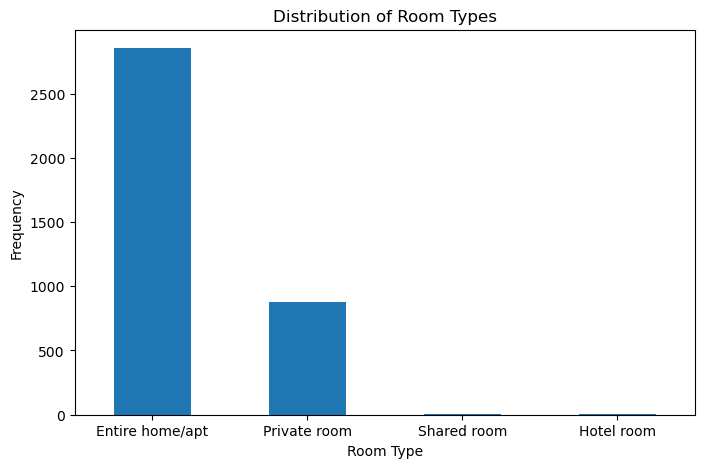

In [13]:
# Distribution of room types
train['room_type'].value_counts().plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Distribution of Room Types')
plt.xlabel('Room Type')
plt.ylabel('Frequency')

plt.xticks(rotation=0)

plt.show()

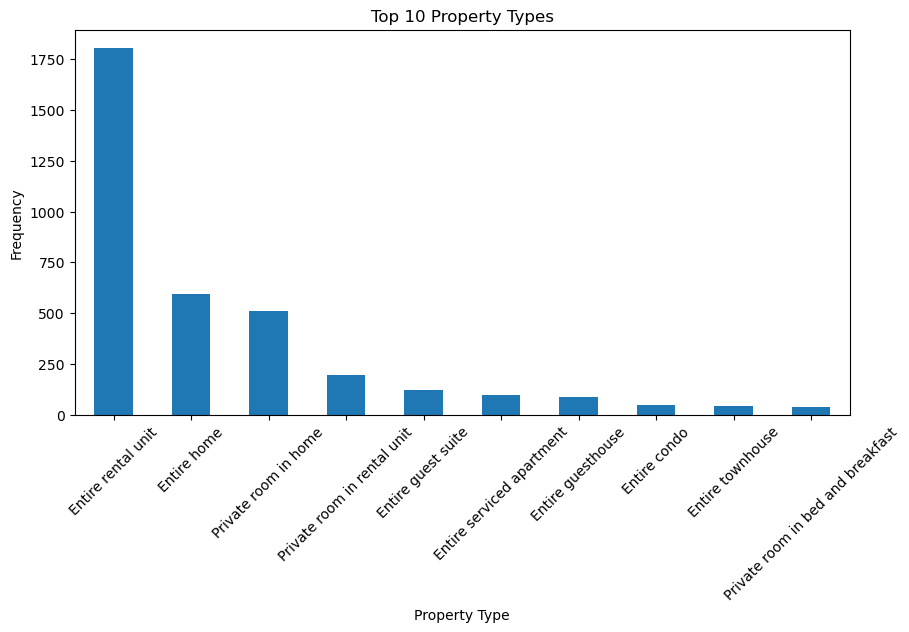

In [14]:
# Top 10 most common property types
train['property_type'].value_counts().head(10).plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Top 10 Property Types')
plt.xlabel('Property Type')
plt.ylabel('Frequency')

plt.xticks(rotation=45)

plt.show()

---- Add your written answer here ------


The univariate analysis provides important insights into the distribution and characteristics of the Airbnb training dataset. Summary statistics and visualisations were used to examine numerical and categorical variables, identify skewness, and detect possible outliers before predictive modelling.

The target variable price shows a strongly right-skewed distribution, as illustrated in both the histogram and boxplot. Most Airbnb listings are concentrated within the lower to moderate price range, while a small number of listings have extremely high prices. The mean listing price is approximately 230  while the median price is around 193  indicating that expensive properties pull the average upward. The maximum recorded price is $5000, confirming the presence of significant outliers and luxury accommodation listings.

The variable accommodates shows that most Airbnb properties host between 2 and 4 guests, suggesting that smaller residential-style accommodations dominate the Brisbane Airbnb market. Similarly, the bedrooms and bathrooms distributions indicate that most listings contain 1 to 2 bedrooms and around 1 bathroom. However, a few listings contain unusually high numbers of bedrooms and bathrooms, which may represent premium or group accommodation properties.

The availability_365 variable displays substantial variation across listings. Some properties are available for only a limited number of days, while many remain available for most of the year. This variation may reflect differences between occasional hosts and highly active commercial hosts.

The number_of_reviews and host_listings_count variables are heavily right-skewed. Most listings receive relatively few reviews and most hosts manage only a small number of properties. However, a small number of properties receive very high review counts, and some hosts manage hundreds of listings. These extreme values indicate possible commercial operators and may influence future predictive modelling.

The categorical analysis shows that Entire home/apartment is the dominant room type, followed by Private room, while Shared room and Hotel room appear very infrequently. Similarly, the most common property type is Entire rental unit, followed by Entire home and Private room in home. Overall, the analysis indicates that the dataset contains skewed distributions and several outliers that may require preprocessing or transformation during later modelling stages.


<hr style="width:25%;margin-left:0;">   

#### 5. Feature Analysis and Selection (2 marks)  
Select at least 20 meaningful features from the dataset.  

- Categorise each feature according to its variable type and present the results in a table (similar to Assignment 1)  
- Analyse how key features relate to the target variable (*price*) using appropriate plots and/or summary statistics  
- Justify your feature selection based on your analysis  
---



In [15]:
# Add your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import f_oneway
from sklearn.feature_selection import mutual_info_regression

train['price'] = train['price'].replace('[\$,]', '', regex=True)
train['price'] = pd.to_numeric(train['price'])



<>:10: SyntaxWarning: invalid escape sequence '\$'
<>:10: SyntaxWarning: invalid escape sequence '\$'
/var/folders/nt/667gntys12b_jd3zbhkyhsl40000gn/T/ipykernel_97568/3799784849.py:10: SyntaxWarning: invalid escape sequence '\$'
  train['price'] = train['price'].replace('[\$,]', '', regex=True)


In [16]:
#selecting candidate variable
selected_features = [
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'property_type',
    'room_type',
    'neighbourhood_cleansed',
    'latitude',
    'longitude',
    'minimum_nights',
    'amenities',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'host_is_superhost',
    'instant_bookable',
    'calculated_host_listings_count'
]

In [17]:
#feature category summery table
feature_category_table = pd.DataFrame({
    'Variable Type': [
        'Numerical discrete',
        'Numerical continuous',
        'Nominal categorical',
        'Binary categorical',
        'Text/List Categorical'
    ],

    'Number of Features': [
        7,
        7,
        3,
        2,
        1
    ],

    'Feature Names': [
        'accommodates, bedrooms, beds, minimum_nights, availability_365, number_of_reviews, calculated_host_listings_count',
        'latitude, longitude, bathrooms, reviews_per_month, review_scores_rating, review_scores_cleanliness, review_scores_location',
        'property_type, room_type, neighbourhood_cleansed',
        'host_is_superhost, instant_bookable',
        'amenities'
    ]
})

display(feature_category_table)

,Variable Type,Number of Features,Feature Names
0,Numerical discrete,7,"accommodates, bedrooms, beds, minimum_nights, ..."
1,Numerical continuous,7,"latitude, longitude, bathrooms, reviews_per_mo..."
2,Nominal categorical,3,"property_type, room_type, neighbourhood_cleansed"
3,Binary categorical,2,"host_is_superhost, instant_bookable"
4,Text/List Categorical,1,amenities


In [18]:
# Detailed variable table
feature_table = pd.DataFrame({
    'Feature': selected_features,

    'Variable Type': [
        'Numerical discrete',      # accommodates
        'Numerical discrete',      # bedrooms
        'Numerical continuous',    # bathrooms
        'Numerical discrete',      # beds
        'Nominal categorical',     # property_type
        'Nominal categorical',     # room_type
        'Nominal categorical',     # neighbourhood_cleansed
        'Numerical continuous',    # latitude
        'Numerical continuous',    # longitude
        'Numerical discrete',      # minimum_nights
        'Text/list categorical',   # amenities
        'Numerical discrete',      # availability_365
        'Numerical discrete',      # number_of_reviews
        'Numerical continuous',    # reviews_per_month
        'Numerical continuous',    # review_scores_rating
        'Numerical continuous',    # review_scores_cleanliness
        'Numerical continuous',    # review_scores_location
        'Binary categorical',      # host_is_superhost
        'Binary categorical',      # instant_bookable
        'Numerical discrete'       # calculated_host_listings_count
    ],

    'Reason for Selection': [
        'Larger guest capacity is usually associated with higher price.',
        'More bedrooms indicate larger property size.',
        'More bathrooms may indicate better facilities and comfort.',
        'More beds increase sleeping capacity.',
        'Different property types have different pricing patterns.',
        'Room privacy strongly affects price.',
        'Location strongly influences accommodation price.',
        'Captures geographical position of the listing.',
        'Captures geographical position of the listing.',
        'Booking restrictions may affect demand and guest suitability.',
        'Contains multiple facility details that may influence listing value and can be transformed into amenity-based features.',
        'Shows yearly listing availability.',
        'Indicates listing popularity and guest activity.',
        'Measures review frequency.',
        'Reflects overall guest satisfaction.',
        'Cleanliness may influence guest willingness to pay.',
        'Location rating may influence price.',
        'Superhost status may increase guest trust.',
        'Instant booking may affect guest convenience and demand.',
        'Shows whether the host is an individual or larger-scale operator.'
    ]
})

display(feature_table)

,Feature,Variable Type,Reason for Selection
0,accommodates,Numerical discrete,Larger guest capacity is usually associated wi...
1,bedrooms,Numerical discrete,More bedrooms indicate larger property size.
2,bathrooms,Numerical continuous,More bathrooms may indicate better facilities ...
3,beds,Numerical discrete,More beds increase sleeping capacity.
4,property_type,Nominal categorical,Different property types have different pricin...
5,room_type,Nominal categorical,Room privacy strongly affects price.
6,neighbourhood_cleansed,Nominal categorical,Location strongly influences accommodation price.
7,latitude,Numerical continuous,Captures geographical position of the listing.
8,longitude,Numerical continuous,Captures geographical position of the listing.
9,minimum_nights,Numerical discrete,Booking restrictions may affect demand and gue...


In [19]:
# Spearman correlation for numerical variables

numeric_features = [
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'latitude',
    'longitude',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'calculated_host_listings_count'
]

spearman_results = []

for feature in numeric_features:
    corr = train[['price', feature]].corr(method='spearman').iloc[0, 1]
    spearman_results.append([feature, corr, abs(corr)])

spearman_table = pd.DataFrame(
    spearman_results,
    columns=[
        'Feature',
        'Spearman Correlation with Price',
        'Absolute Correlation'
    ]
).sort_values(by='Absolute Correlation', ascending=False)

display(spearman_table)

,Feature,Spearman Correlation with Price,Absolute Correlation
0,accommodates,0.661410,0.661410
1,bedrooms,0.599949,0.599949
3,beds,0.582004,0.582004
2,bathrooms,0.449922,0.449922
13,calculated_host_listings_count,0.194020,0.194020
12,review_scores_location,0.173018,0.173018
4,latitude,0.118271,0.118271
8,number_of_reviews,-0.094692,0.094692
6,minimum_nights,0.090887,0.090887
9,reviews_per_month,-0.045290,0.045290


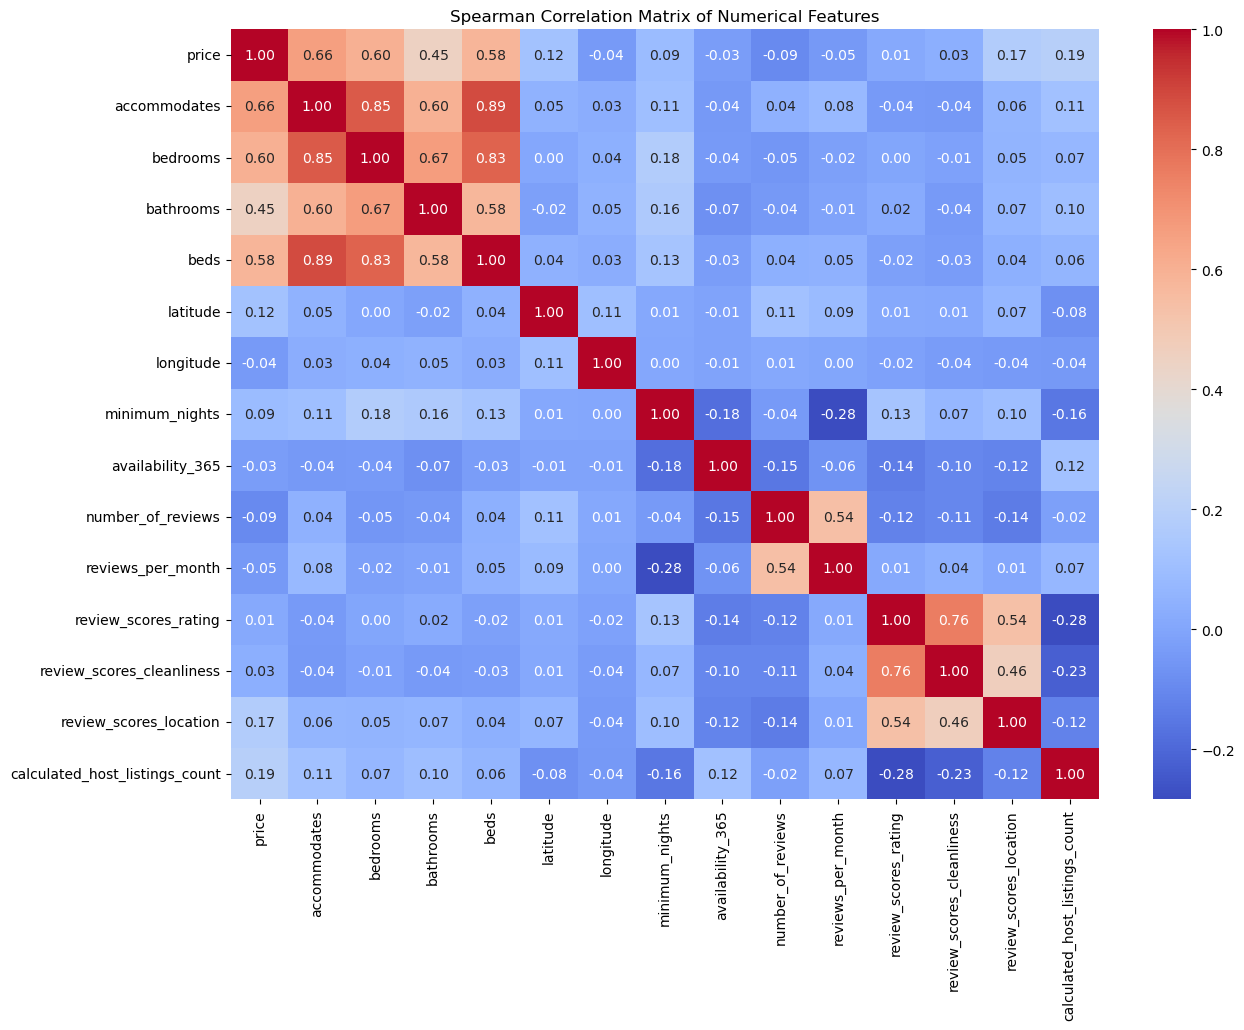

In [20]:
#spearman heat map
corr_features = ['price'] + numeric_features

spearman_matrix = train[corr_features].corr(method='spearman')

plt.figure(figsize=(14, 10))

sns.heatmap(
    spearman_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Spearman Correlation Matrix of Numerical Features')
plt.show()

In [21]:
#ANOVA categorial variable
categorical_features = [
    'room_type',
    'property_type',
    'neighbourhood_cleansed',
    'host_is_superhost',
    'instant_bookable'
]

anova_results = []

for feature in categorical_features:
    groups = [
        group['price'].dropna()
        for name, group in train.groupby(feature)
        if len(group['price'].dropna()) > 1
    ]

    if len(groups) > 1:
        f_stat, p_value = f_oneway(*groups)
        anova_results.append([feature, f_stat, p_value])

anova_table = pd.DataFrame(
    anova_results,
    columns=['Feature', 'F-statistic', 'p-value']
).sort_values(by='p-value')

display(anova_table)

,Feature,F-statistic,p-value
1,property_type,31.648794,4.853893e-159
0,room_type,135.380569,2.953963e-83
2,neighbourhood_cleansed,5.557060,1.234577e-72
4,instant_bookable,1.536939,2.151519e-01
3,host_is_superhost,0.122223,7.266562e-01


In [22]:
# Median price by categorical variables, with category counts

for feature in categorical_features:
    print(f"\nMedian price by {feature}:")

    median_table = (
        train.groupby(feature)['price']
        .agg(['count', 'median'])
        .sort_values(by='median', ascending=False)
        .head(10)
    )

    display(median_table)


Median price by room_type:


,count,median
room_type,,
Hotel room,2,349.5
Entire home/apt,2854,217.0
Private room,875,91.0
Shared room,4,47.5



Median price by property_type:


,count,median
property_type,,
Tent,1,998.0
Room in serviced apartment,1,441.0
Earthen home,1,415.0
Room in hotel,35,390.0
Room in aparthotel,5,372.0
Barn,1,338.0
Entire villa,6,336.0
Holiday park,1,320.0
Entire serviced apartment,96,299.5



Median price by neighbourhood_cleansed:


,count,median
neighbourhood_cleansed,,
Hendra,3,1336.0
Wakerley,2,699.5
Moreton Island,26,572.0
Westlake,3,477.0
Fig Tree Pocket,9,310.0
Windsor,24,294.0
Brookfield - Kenmore Hills,11,273.0
Rochedale - Burbank,16,264.0
Carindale,15,263.0



Median price by host_is_superhost:


,count,median
host_is_superhost,,
f,2323,194.0
t,1275,185.0



Median price by instant_bookable:


,count,median
instant_bookable,,
t,1219,201.0
f,2516,185.0


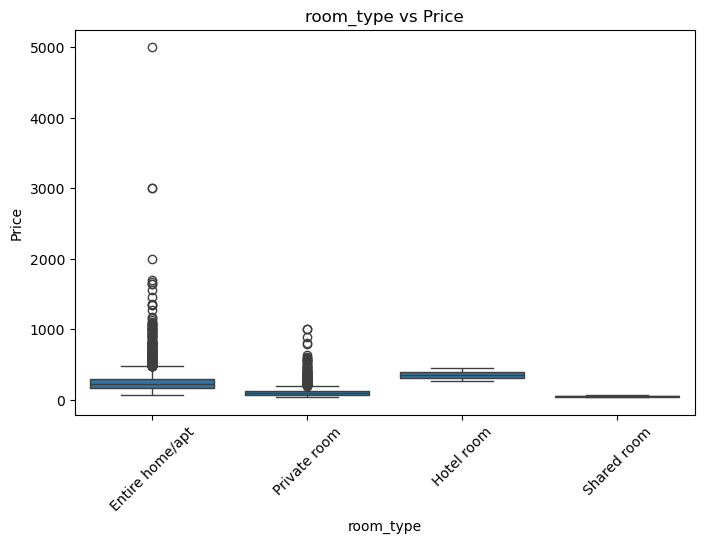

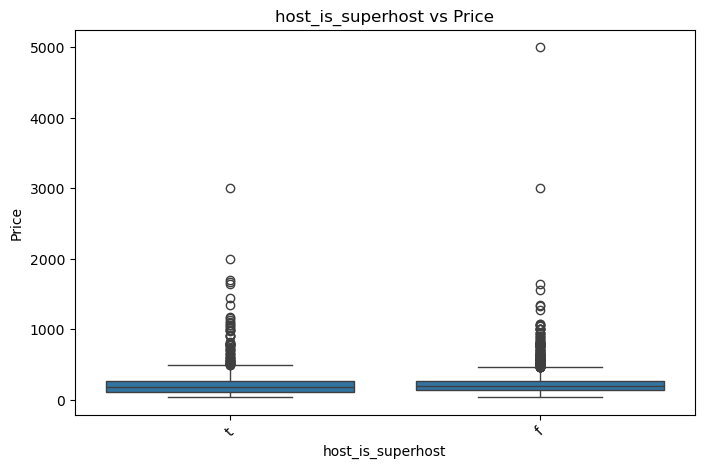

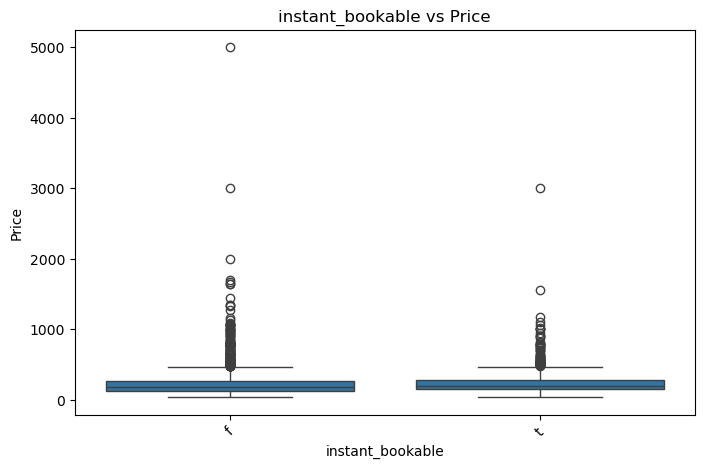

In [23]:
#Boxplots for categorical features
boxplot_features = [
    'room_type',
    'host_is_superhost',
    'instant_bookable'
]

for feature in boxplot_features:
    plt.figure(figsize=(8, 5))

    sns.boxplot(
        x=feature,
        y='price',
        data=train
    )

    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
    plt.xticks(rotation=45)
    plt.show()

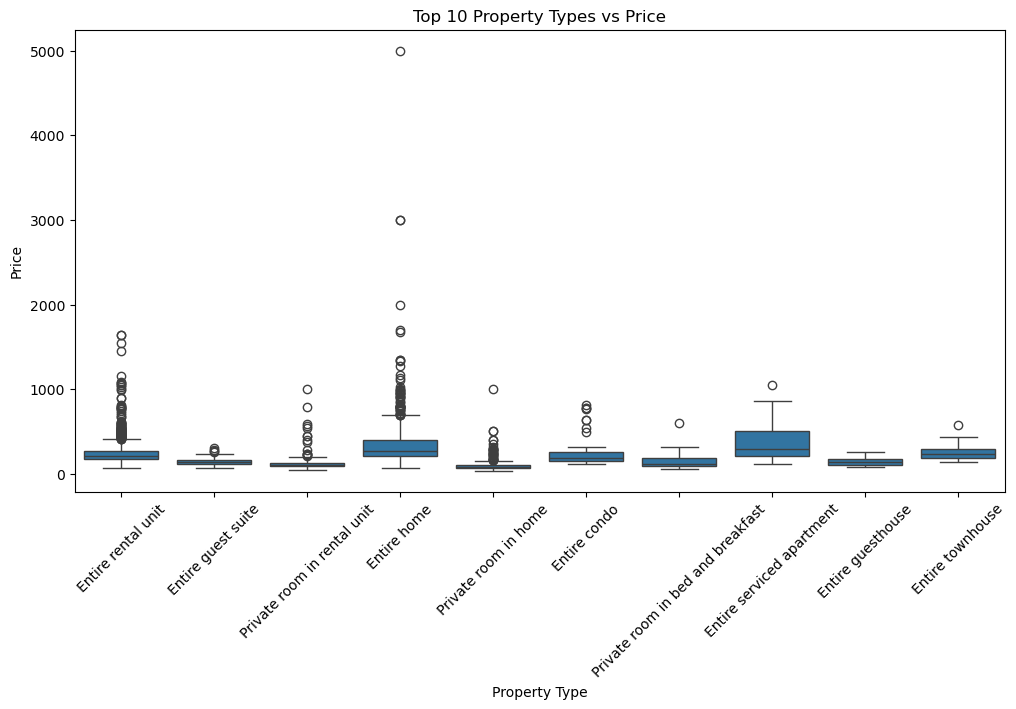

In [24]:
#Box plot by 10 property type
top_property_types = train['property_type'].value_counts().head(10).index

filtered_property_data = train[
    train['property_type'].isin(top_property_types)
]

plt.figure(figsize=(12, 6))

sns.boxplot(
    x='property_type',
    y='price',
    data=filtered_property_data
)

plt.title('Top 10 Property Types vs Price')
plt.xlabel('Property Type')
plt.ylabel('Price')
plt.xticks(rotation=45)

plt.show()


neighbourhood_cleansed
Hendra                        1336.0
Wakerley                       699.5
Moreton Island                 572.0
Westlake                       477.0
Fig Tree Pocket                310.0
Windsor                        294.0
Brookfield - Kenmore Hills     273.0
Rochedale - Burbank            264.0
Carindale                      263.0
Balmoral                       251.0
Name: price, dtype: float64

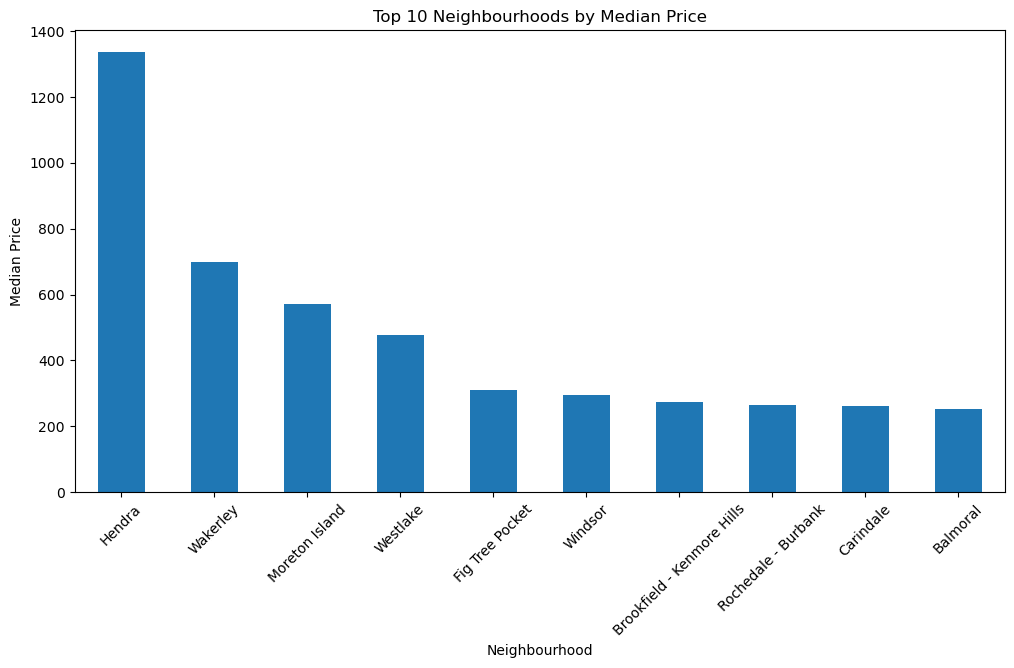

In [25]:
#Top neighbourhoods by median price
top_neighbourhood_prices = (
    train.groupby('neighbourhood_cleansed')['price']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

display(top_neighbourhood_prices)

top_neighbourhood_prices.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Top 10 Neighbourhoods by Median Price')
plt.xlabel('Neighbourhood')
plt.ylabel('Median Price')
plt.xticks(rotation=45)

plt.show()

In [26]:
mi_data = train[selected_features + ['price']].copy()

# Numerical features only
numeric_features_for_imputation = [
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'latitude',
    'longitude',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'calculated_host_listings_count'
]

# Categorical features only
categorical_features_for_imputation = [
    'property_type',
    'room_type',
    'neighbourhood_cleansed',
    'host_is_superhost',
    'instant_bookable'
]

# Fill missing numerical values with median
for col in numeric_features_for_imputation:
    if col in mi_data.columns:
        mi_data[col] = mi_data[col].fillna(mi_data[col].median())

# Fill missing categorical values with mode
for col in categorical_features_for_imputation:
    if col in mi_data.columns:
        mi_data[col] = mi_data[col].fillna(mi_data[col].mode()[0])

# Exclude amenities from MI because it is a text/list variable
mi_features = [
    feature for feature in selected_features
    if feature != 'amenities'
]

# One-hot encode categorical variables
mi_encoded = pd.get_dummies(
    mi_data[mi_features],
    drop_first=True
)

X = mi_encoded
y = mi_data['price']

mi_scores = mutual_info_regression(X, y, random_state=42)

mi_table = pd.DataFrame({
    'Feature': X.columns,
    'Mutual Information Score': mi_scores
}).sort_values(by='Mutual Information Score', ascending=False)

display(mi_table.head(20))

,Feature,Mutual Information Score
0,accommodates,0.352563
55,room_type_Private room,0.264173
3,beds,0.259769
1,bedrooms,0.254731
13,calculated_host_listings_count,0.232673
4,latitude,0.223066
39,property_type_Private room in home,0.197218
5,longitude,0.190234
2,bathrooms,0.190155
26,property_type_Entire rental unit,0.136571


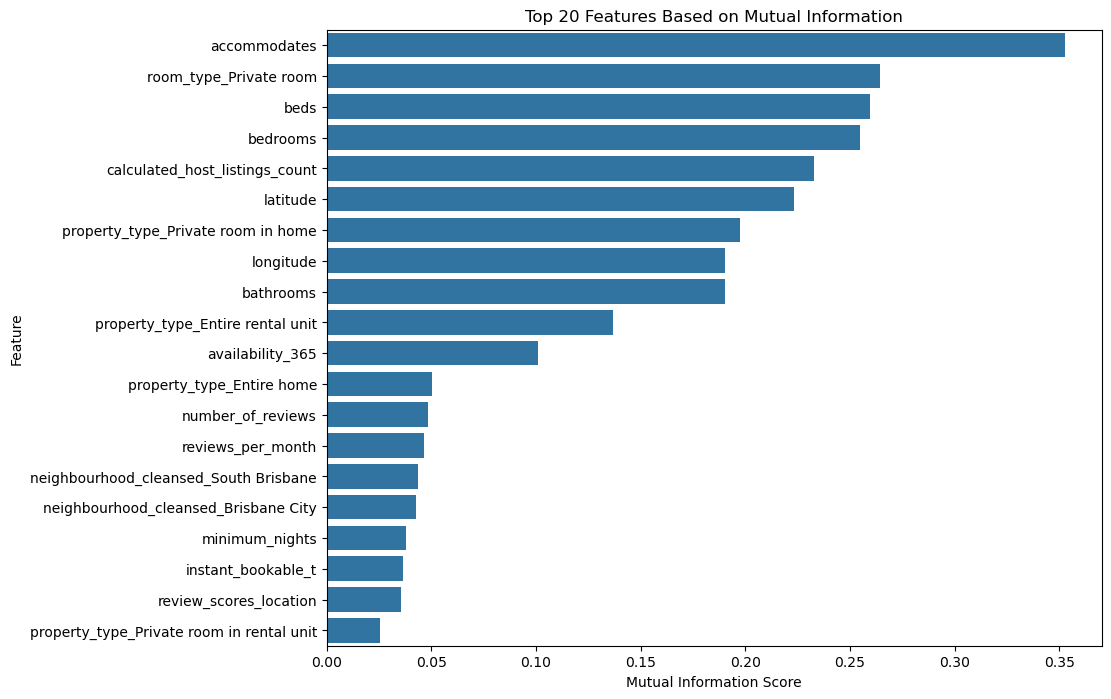

In [27]:
#Plot top mutual information features
top_mi_features = mi_table.head(20)

plt.figure(figsize=(10, 8))

sns.barplot(
    x='Mutual Information Score',
    y='Feature',
    data=top_mi_features
)

plt.title('Top 20 Features Based on Mutual Information')
plt.xlabel('Mutual Information Score')
plt.ylabel('Feature')

plt.show()

The feature analysis demonstrates that the selected variables have meaningful relationships with the target variable, `price`. The selected features represent important aspects of Airbnb pricing behaviour, including property size, room type, property type, location, booking restrictions, availability, guest reviews, amenities, and host characteristics.

The numerical variables were analysed using Spearman correlation rather than Pearson correlation because Airbnb listing prices are highly skewed, contain extreme outliers, and may include non-linear relationships. Spearman correlation is more appropriate in this context because it measures monotonic relationships rather than only simple linear relationships. The results show that property-size variables have the strongest positive relationships with price. Among the numerical features, `accommodates` has the highest correlation with price, followed by `bedrooms`, `beds`, and `bathrooms`. These findings suggest that larger properties with greater guest capacity and more facilities generally have higher listing prices.

The correlation matrix also reveals strong relationships between some numerical features themselves. For example, `accommodates`, `bedrooms`, and `beds` are highly related because larger properties usually contain more sleeping capacity. This supports the idea that property size is one of the most important pricing factors in the Brisbane Airbnb market.

Some variables show relatively weak individual correlations with price but are still meaningful for exploratory analysis. For example, `review_scores_rating`, `review_scores_cleanliness`, `availability_365`, and `longitude` show weak direct correlations with price. However, this does not necessarily mean these variables are unimportant. Airbnb prices are influenced by multiple interacting factors, and some variables may become more useful when considered together with room type, property type, location, reviews, and amenities.

Variables such as `review_scores_location` and `calculated_host_listings_count` show weaker but still meaningful positive relationships with price. This suggests that listings in more desirable locations and listings managed by larger-scale hosts may have different pricing patterns. In contrast, `number_of_reviews` and `reviews_per_month` show slight negative relationships with price, which may indicate that more affordable listings receive bookings more frequently and therefore accumulate more reviews.

The raw `amenities` variable was selected because it contains detailed information about the facilities offered by each listing. It is not included in the numerical correlation matrix because it is stored as a text/list categorical variable rather than a direct numerical variable. However, it is still highly relevant because amenities such as parking, pool, gym, air conditioning, washer, dryer, balcony, and kitchen-related facilities may influence guest comfort and perceived listing value. This variable will be transformed into numerical amenity-based features during Task 2.

The categorical analysis demonstrates clear pricing differences across room types and property types. The boxplots show that entire home/apartment listings generally have higher prices than private rooms and shared rooms. Hotel rooms show a high median price in the sample, but this category contains very few observations, so it should be interpreted cautiously. Overall, the results suggest that privacy, exclusive access, and accommodation style strongly influence Airbnb pricing.

Similarly, the property type analysis shows substantial pricing differences across accommodation styles. Property types such as entire homes, serviced apartments, and other full-property listings generally command higher prices than smaller or shared accommodation types. The presence of extreme outliers in several categories also reflects the existence of luxury or premium listings in the dataset.

The neighbourhood analysis confirms that location is an important pricing factor. Median prices vary across Brisbane neighbourhoods, which suggests that guests may be willing to pay different prices depending on suburb, accessibility, tourism appeal, and surrounding amenities. However, neighbourhood medians based on very small category counts should be interpreted carefully, as a small number of listings can strongly affect the median.

The ANOVA analysis provides additional evidence that categorical variables such as `property_type`, `room_type`, and `neighbourhood_cleansed` are associated with statistically significant price differences across categories. In contrast, variables such as `host_is_superhost` and `instant_bookable` appear to have weaker direct relationships with price. This suggests that property type, room type, and location are stronger categorical pricing factors than host badge status or instant booking availability.

The Mutual Information analysis was used as an additional exploratory tool because it can capture non-linear relationships between variables and price. The raw `amenities` field was excluded from this calculation because it is a text/list variable and is not directly suitable for Mutual Information without transformation. The results indicate that property-size variables such as `accommodates`, `beds`, `bedrooms`, and `bathrooms`, along with room type, location-related variables, and host listing count, contain useful information about price variation.

Overall, the selected features were chosen based on practical Airbnb pricing knowledge, Spearman correlation analysis for numerical variables, boxplots and grouped median prices for categorical variables, ANOVA results, Mutual Information scores, and missing-value considerations. The selected variables cover the main factors likely to influence Airbnb prices: property size, room privacy, property type, location, availability, reviews, amenities, and host characteristics. The replacement of `maximum_nights` with `amenities` was made because `amenities` contains richer facility-level information and can be transformed into useful numerical features during Task 2. This supports the later feature engineering process while keeping the selected feature set meaningful and aligned with Airbnb pricing behaviour.

---
---

## Task 2: Data Cleaning, Missing Observations and Feature Engineering

**Total Marks: 10**

- Use the features selected in **Task 1, Question 5** for this task.  
- Ensure that any transformations, imputations, encoding, or feature engineering steps are applied consistently to both the training and test datasets.  
- Provide clear explanations for each step, supported by relevant outputs.

Student in charge of this task: `Sakshi Chhapru`

<hr style="width:25%;margin-left:0;">   

#### 1. Numerical Data Cleaning (2 marks)

Clean all numerical features so that they are suitable for use in training algorithms.
- Extract numerical values from text-based fields where necessary
- Remove non-numeric characters %, $, commas, etc.
- Briefly describe the steps you take

In [28]:
# Numerical Data Cleaning

import pandas as pd
import numpy as np

# Load datasets
train_clean = pd.read_csv("train.csv")
test_clean = pd.read_csv("test.csv")

# Updated selected features from Task 1, Question 5
selected_features = [
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'property_type',
    'room_type',
    'neighbourhood_cleansed',
    'latitude',
    'longitude',
    'minimum_nights',
    'amenities',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'host_is_superhost',
    'instant_bookable',
    'calculated_host_listings_count'
]

# Numerical predictor variables from the selected feature set
# Note: amenities is not included here because it is a text/list categorical variable
numerical_features = [
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'latitude',
    'longitude',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'calculated_host_listings_count'
]

# Display original price format before cleaning
price_before_cleaning = train_clean['price'].head(5).copy()

# Clean the target variable price:
# remove dollar signs and commas, then convert to numeric
train_clean['price'] = pd.to_numeric(
    train_clean['price']
    .astype(str)
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False),
    errors='coerce'
)

# Ensure selected numerical predictors are stored as numeric
# The same conversion is applied to both training and test datasets
cleaning_summary = []

for feature in numerical_features:
    train_missing_before = train_clean[feature].isna().sum()
    test_missing_before = test_clean[feature].isna().sum()

    train_clean[feature] = pd.to_numeric(train_clean[feature], errors='coerce')
    test_clean[feature] = pd.to_numeric(test_clean[feature], errors='coerce')

    train_missing_after = train_clean[feature].isna().sum()
    test_missing_after = test_clean[feature].isna().sum()

    cleaning_summary.append({
        'Feature': feature,
        'Train Data Type': train_clean[feature].dtype,
        'Test Data Type': test_clean[feature].dtype,
        'New Invalid Values in Train': train_missing_after - train_missing_before,
        'New Invalid Values in Test': test_missing_after - test_missing_before,
        'Remaining Missing Values in Train': train_missing_after,
        'Remaining Missing Values in Test': test_missing_after
    })

# Show price cleaning example
price_cleaning_example = pd.DataFrame({
    'Price Before Cleaning': price_before_cleaning,
    'Price After Cleaning': train_clean['price'].head(5)
})

print("Example of price cleaning:")
display(price_cleaning_example)

# Show numerical cleaning summary
cleaning_summary_table = pd.DataFrame(cleaning_summary)

print("Numerical Feature Cleaning Summary:")
display(cleaning_summary_table)

# Confirm target variable cleaning
print("Datatype of cleaned price:", train_clean['price'].dtype)
print("Missing values in cleaned price:", train_clean['price'].isna().sum())

# Confirm amenities is not treated as numerical
print("Datatype of amenities:", train_clean['amenities'].dtype)
print("Missing values in amenities - train:", train_clean['amenities'].isna().sum())
print("Missing values in amenities - test:", test_clean['amenities'].isna().sum())

Example of price cleaning:


,Price Before Cleaning,Price After Cleaning
0,$97.00,97.0
1,$205.00,205.0
2,$186.00,186.0
3,$157.00,157.0
4,$300.00,300.0


Numerical Feature Cleaning Summary:


,Feature,Train Data Type,Test Data Type,New Invalid Values in Train,New Invalid Values in Test,Remaining Missing Values in Train,Remaining Missing Values in Test
0,accommodates,int64,int64,0,0,0,0
1,bedrooms,float64,float64,0,0,2,1
2,bathrooms,float64,float64,0,0,5,0
3,beds,float64,float64,0,0,3,0
4,latitude,float64,float64,0,0,0,0
5,longitude,float64,float64,0,0,0,0
6,minimum_nights,int64,int64,0,0,0,0
7,availability_365,int64,int64,0,0,0,0
8,number_of_reviews,int64,int64,0,0,0,0
9,reviews_per_month,float64,float64,0,0,437,183


Datatype of cleaned price: float64
Missing values in cleaned price: 0
Datatype of amenities: object
Missing values in amenities - train: 0
Missing values in amenities - test: 0


---- Add your written answer here ------

Numerical data cleaning was performed on the  selected features from Task 1 to ensure that numerical variables were stored in a format suitable for later analysis and modelling. The target variable, `price`, was originally stored as a text field containing non-numeric characters such as dollar signs and comma separators. These symbols were removed and `price` was converted into numeric format. This step was necessary because mathematical calculations, summary statistics and model training require the target variable to be represented numerically.

The selected numerical predictor variables were then checked and converted consistently in both the training and test datasets. These variables include property-size measures such as `accommodates`, `bedrooms`, `bathrooms` and `beds`; geographical coordinates such as `latitude` and `longitude`; booking and availability variables such as `minimum_nights` and `availability_365`; review-related variables; and `calculated_host_listings_count`. Applying the same conversion process to both datasets ensures that the training and test data remain consistent for later preprocessing and forecasting.

The output confirms that all selected numerical variables are stored as appropriate numeric data types, either `int64` or `float64`. The conversion process created zero new invalid values in both datasets, which means that valid numerical information was preserved during cleaning. The cleaned `price` variable is stored as `float64` and contains no missing values after conversion.


Some numerical variables still contain missing values, especially review-related variables such as `reviews_per_month`, `review_scores_rating`, `review_scores_cleanliness` and `review_scores_location`. These missing values were not imputed in this section because missing-value treatment is addressed separately in Question 3. Therefore, this step focuses only on ensuring that numerical data are correctly formatted before later cleaning stages.

<hr style="width:25%;margin-left:0;">    

#### 2. Feature Engineering (2 marks)

Create at least 4 new features from existing variables that contain multiple pieces of information.  
- Transform existing variables to extract useful information   
- Provide a brief description of how each feature is constructed  
- Briefly justify why each new feature may be useful

In [29]:
# Add your code here
# Feature Engineering

import numpy as np
import pandas as pd
import ast

# Create copies of the cleaned datasets from Question 1
train_engineered = train_clean.copy()
test_engineered = test_clean.copy()


# Feature 1: CBD coordinate distance

# Brisbane CBD reference coordinates
CBD_LATITUDE = -27.4698
CBD_LONGITUDE = 153.0251

train_engineered['cbd_coordinate_distance'] = np.sqrt(
    (train_engineered['latitude'] - CBD_LATITUDE) ** 2
    + (train_engineered['longitude'] - CBD_LONGITUDE) ** 2
)

test_engineered['cbd_coordinate_distance'] = np.sqrt(
    (test_engineered['latitude'] - CBD_LATITUDE) ** 2
    + (test_engineered['longitude'] - CBD_LONGITUDE) ** 2
)


# Feature 2: Space per guest ratio


train_engineered['space_per_guest_ratio'] = (
    train_engineered['bedrooms']
    + train_engineered['bathrooms']
    + train_engineered['beds']
) / train_engineered['accommodates']

test_engineered['space_per_guest_ratio'] = (
    test_engineered['bedrooms']
    + test_engineered['bathrooms']
    + test_engineered['beds']
) / test_engineered['accommodates']


# Feature 3: Amenity value score


premium_amenities = [
    'pool',
    'gym',
    'parking',
    'air conditioning',
    'hot tub',
    'sauna',
    'waterfront',
    'river view',
    'patio or balcony',
    'dishwasher',
    'washer',
    'dryer'
]

def parse_amenities(amenities_text):
    if pd.isna(amenities_text):
        return []

    try:
        amenities_list = ast.literal_eval(amenities_text)
        if isinstance(amenities_list, list):
            return amenities_list
        return []
    except:
        return []

def calculate_amenity_value_score(amenities_text):
    amenities_list = parse_amenities(amenities_text)
    amenities_lower = [amenity.lower() for amenity in amenities_list]

    total_amenities = len(amenities_lower)

    premium_count = 0
    for premium in premium_amenities:
        if any(premium in amenity for amenity in amenities_lower):
            premium_count += 1

    return total_amenities + premium_count

train_engineered['amenity_value_score'] = train_engineered['amenities'].apply(
    calculate_amenity_value_score
)

test_engineered['amenity_value_score'] = test_engineered['amenities'].apply(
    calculate_amenity_value_score
)


# Feature 4: Review trust score


review_score_features = [
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location'
]

train_engineered['average_review_score'] = train_engineered[
    review_score_features
].mean(axis=1)

test_engineered['average_review_score'] = test_engineered[
    review_score_features
].mean(axis=1)

train_engineered['review_trust_score'] = (
    train_engineered['average_review_score']
    * np.log1p(train_engineered['number_of_reviews'])
)

test_engineered['review_trust_score'] = (
    test_engineered['average_review_score']
    * np.log1p(test_engineered['number_of_reviews'])
)


# Display engineered feature outputs


engineered_features = [
    'cbd_coordinate_distance',
    'space_per_guest_ratio',
    'amenity_value_score',
    'review_trust_score'
]

print("Example of Engineered Features in Training Data:")
display(train_engineered[engineered_features].head())

print("Summary Statistics for Engineered Features:")
display(train_engineered[engineered_features].describe().T.round(2))

engineered_missing_summary = pd.DataFrame({
    'Train Missing Values': train_engineered[engineered_features].isnull().sum(),
    'Test Missing Values': test_engineered[engineered_features].isnull().sum()
})

print("Missing Values in Engineered Features:")
display(engineered_missing_summary)


Example of Engineered Features in Training Data:


,cbd_coordinate_distance,space_per_guest_ratio,amenity_value_score,review_trust_score
0,0.087653,1.500000,21,13.034050
1,0.155851,1.500000,37,13.996074
2,0.015591,1.500000,37,15.594717
3,0.020852,2.000000,29,NaN
4,0.017108,1.333333,53,15.297032


Summary Statistics for Engineered Features:


,count,mean,std,min,25%,50%,75%,max
cbd_coordinate_distance,3735.0,0.05,0.06,0.00,0.01,0.03,0.08,0.52
space_per_guest_ratio,3725.0,1.57,0.62,0.50,1.29,1.50,1.50,11.00
amenity_value_score,3735.0,44.42,16.85,0.00,34.50,47.00,56.00,90.00
review_trust_score,3298.0,15.19,6.72,0.69,10.26,15.29,20.02,33.84


Missing Values in Engineered Features:


,Train Missing Values,Test Missing Values
cbd_coordinate_distance,0,0
space_per_guest_ratio,10,1
amenity_value_score,0,0
review_trust_score,437,183


---- Add your written answer here ------


Four new features were created from the variables selected in Task 1, and the same feature-engineering steps were applied consistently to both the training and test datasets.

First, `cbd_coordinate_distance` was created using each listing's latitude and longitude relative to a fixed Brisbane CBD reference point. A Euclidean-style coordinate distance was used to provide a simple measure of how close each listing is to central Brisbane. This is not an exact kilometre distance, but it provides an interpretable location-based measure within the Brisbane market. This feature is useful because listings closer to central Brisbane may be more attractive to guests due to easier access to transport, restaurants, business areas and tourist attractions. The output shows that this feature was successfully created for all observations, with no missing values in either dataset.

Second, `space_per_guest_ratio` was calculated by dividing the combined number of bedrooms, bathrooms and beds by the number of guests the listing accommodates. This feature captures how much sleeping and facility provision is available relative to guest capacity. It can prove to be useful because two listings can accommodate the same number of guests but offer different levels of comfort and space. A higher ratio indicates a more spacious or better-equipped listing relative to its guest capacity. The training data shows a median value of 1.50. The feature contains 10 missing values in the training data and 1 missing value in the test data because some of the original variables used in its calculation contain missing observations.

Third, `amenity_value_score` was created from the `amenities` field. The total number of amenities was counted, and additional value was added for selected premium amenities such as pool, gym, parking, air conditioning, hot tub, sauna, waterfront-related features, balcony, dishwasher, washer and dryer.The premium amenity list was manually defined using domain knowledge, and the code counted how many of those amenities appeared in each listing's original amenities field. This feature can be useful because amenities contribute to guest comfort, convenience and perceived listing quality. Listings with more amenities, especially premium amenities, may be able to justify higher prices compared with listings offering fewer facilities. The output shows that `amenity_value_score` was successfully created with no missing values in either dataset. In the training data, the median score is 47, with values ranging from 0 to 90.

Finally, `review_trust_score` was created by combining review quality with the amount of review evidence. The average review score was calculated from `review_scores_rating`, `review_scores_cleanliness` and `review_scores_location`, and then multiplied by `log(1 + number_of_reviews)`. The logarithmic transformation reduces the influence of extremely high review counts while still giving greater weight to ratings supported by more reviews. This feature can be useful because a high rating based on many reviews is generally more reliable than a high rating based on only one or two reviews. It therefore captures both perceived listing quality and the strength of review evidence. The training data shows a median `review_trust_score` of 15.29. This feature contains 437 missing values in the training data and 183 missing values in the test data because some listings do not have review score information.

Overall, the engineered features capture four different aspects of Airbnb pricing: central location, space and facility provision, amenity value, and review-based trust. Missing values remain in `space_per_guest_ratio` and `review_trust_score` because their source variables contain missing observations. These missing values are retained at this stage and will be handled in the missing-value imputation section.

<hr style="width:25%;margin-left:0;">     

#### 3. Missing Values (2 marks)

Impute missing values for all selected features.  
- Identify variables with missing values  
- Apply appropriate imputation methods (e.g. mean, median, mode, or other suitable approaches)  
- Ensure that the same imputation strategy is applied consistently to both datasets  
- Briefly explain and justify the method used for different types of variable


In [30]:
# Add your code here

# Missing Values


# Final features used after feature engineering
engineered_features = [
    'cbd_coordinate_distance',
    'space_per_guest_ratio',
    'amenity_value_score',
    'review_trust_score'
]

final_features = selected_features + engineered_features

# Check missing values before imputation
missing_before = pd.DataFrame({
    'Train Missing Before': train_engineered[final_features].isnull().sum(),
    'Test Missing Before': test_engineered[final_features].isnull().sum()
})

missing_before = missing_before[
    (missing_before['Train Missing Before'] > 0) |
    (missing_before['Test Missing Before'] > 0)
]

print("Missing Values Before Imputation:")
display(missing_before)

Missing Values Before Imputation:


,Train Missing Before,Test Missing Before
bedrooms,2,1
bathrooms,5,0
beds,3,0
reviews_per_month,437,183
review_scores_rating,437,183
review_scores_cleanliness,437,183
review_scores_location,437,183
host_is_superhost,137,56
space_per_guest_ratio,10,1
review_trust_score,437,183


In [31]:
# Create imputed copies
train_imputed = train_engineered.copy()
test_imputed = test_engineered.copy()


# 1. Median imputation for selected numerical variables


median_impute_features = [
    'bedrooms',
    'bathrooms',
    'beds',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location'
]

for feature in median_impute_features:
    median_value = train_imputed[feature].median()

    train_imputed[feature] = train_imputed[feature].fillna(median_value)
    test_imputed[feature] = test_imputed[feature].fillna(median_value)


# 2. Review activity imputation


# Missing reviews_per_month means no recorded review activity,
# so it is filled with 0.
train_imputed['reviews_per_month'] = train_imputed['reviews_per_month'].fillna(0)
test_imputed['reviews_per_month'] = test_imputed['reviews_per_month'].fillna(0)


# 3. Categorical missing value imputation


# Missing superhost status is treated as Unknown.
train_imputed['host_is_superhost'] = train_imputed['host_is_superhost'].fillna('Unknown')
test_imputed['host_is_superhost'] = test_imputed['host_is_superhost'].fillna('Unknown')


# 4. Recalculate engineered features affected by imputation


# Recalculate space_per_guest_ratio after imputing bedrooms, bathrooms and beds
train_imputed['space_per_guest_ratio'] = (
    train_imputed['bedrooms']
    + train_imputed['bathrooms']
    + train_imputed['beds']
) / train_imputed['accommodates']

test_imputed['space_per_guest_ratio'] = (
    test_imputed['bedrooms']
    + test_imputed['bathrooms']
    + test_imputed['beds']
) / test_imputed['accommodates']

# Recalculate review_trust_score after imputing review scores
review_score_features = [
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location'
]

train_imputed['average_review_score'] = train_imputed[
    review_score_features
].mean(axis=1)

test_imputed['average_review_score'] = test_imputed[
    review_score_features
].mean(axis=1)

train_imputed['review_trust_score'] = (
    train_imputed['average_review_score']
    * np.log1p(train_imputed['number_of_reviews'])
)

test_imputed['review_trust_score'] = (
    test_imputed['average_review_score']
    * np.log1p(test_imputed['number_of_reviews'])
)

In [32]:
# Check missing values after imputation
missing_after = pd.DataFrame({
    'Train Missing After': train_imputed[final_features].isnull().sum(),
    'Test Missing After': test_imputed[final_features].isnull().sum()
})

missing_after = missing_after[
    (missing_after['Train Missing After'] > 0) |
    (missing_after['Test Missing After'] > 0)
]

print("Missing Values After Imputation:")
display(missing_after)

print("Total missing values in final training features:",
      train_imputed[final_features].isnull().sum().sum())

print("Total missing values in final test features:",
      test_imputed[final_features].isnull().sum().sum())

Missing Values After Imputation:


,Train Missing After,Test Missing After


Total missing values in final training features: 0
Total missing values in final test features: 0


---- Add your written answer here ------



Missing values were examined for all selected features from Task 1 and the engineered features created in Task 2. This step was necessary because most machine learning algorithms cannot directly handle missing values, and leaving them untreated would cause errors during model fitting. The same imputation strategy was applied consistently to both the training and test datasets. All imputation values were calculated from the training dataset only to avoid using information from the test dataset during preprocessing.

For numerical variables such as `bedrooms`, `bathrooms`, `beds`, `review_scores_rating`, `review_scores_cleanliness` and `review_scores_location`, missing values were replaced using the training median. Median imputation was chosen because these variables may contain skewness or unusual values. For example, some listings may have unusually high numbers of beds or bathrooms, and some review scores may be unusually low. The median is less affected by such extreme values than the mean, making it a more robust choice.

The variable `reviews_per_month` was treated separately because its missing values have a specific meaning in this dataset. Missing values in this column occur for listings with no recorded reviews. Therefore, these missing values were replaced with 0 rather than the median. This is more meaningful because 0 represents no observed monthly review activity, while using the median would incorrectly suggest that an unreviewed listing has a typical level of review activity.

For the categorical variable `host_is_superhost`, missing values were not recoded as either `t` or `f`, because doing so would incorrectly assume the host's superhost status. A missing value does not necessarily mean the host is or is not a superhost. Therefore, missing values were assigned to a separate `"Unknown"` category. This preserves the distinction between known superhost status and unreported status, and allows the missing status itself to be retained as information during categorical encoding.

After imputing the original variables, engineered features affected by missing source variables were recalculated. `space_per_guest_ratio` was recalculated after imputing `bedrooms`, `bathrooms` and `beds`, because this feature is directly constructed from those variables. Similarly, `review_trust_score` was recalculated after imputing the review score variables, because it depends on the average review score. Recalculating these engineered features ensures that they remain consistent with the cleaned source variables rather than containing outdated missing values.

The final missing-value check confirms that no missing values remain in the selected and engineered features in either the training or test dataset. This means the data is complete and ready for categorical encoding and final preparation before modelling.

<hr style="width:25%;margin-left:0;">   

#### 4. Encoding Categorical Variables (2 marks)

Encode all categorical variables appropriately.  
- Identify all categorical features in the dataset  
- For features with more than 5 unique values, retain the 5 most frequent categories and group the remaining values into an "other" category  
- Apply an appropriate encoding method, i.e. ordinal vs. nominal  
- Ensure that encoding is applied consistently to both the training and test datasets  
- Briefly explain your encoding choices


In [33]:
# Add your code here

# Encoding Categorical Variables

import pandas as pd


# 1. Define final feature set for modelling/preparation


# The raw amenities column is excluded because it has already been
# transformed into amenity_value_score during feature engineering.
final_features_for_encoding = [
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'property_type',
    'room_type',
    'neighbourhood_cleansed',
    'latitude',
    'longitude',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'host_is_superhost',
    'instant_bookable',
    'calculated_host_listings_count',
    'cbd_coordinate_distance',
    'space_per_guest_ratio',
    'amenity_value_score',
    'review_trust_score'
]

# Create feature-only copies
X_train_for_encoding = train_imputed[final_features_for_encoding].copy()
X_test_for_encoding = test_imputed[final_features_for_encoding].copy()


# 2. Identify categorical features and encoding method


categorical_encoding_plan = pd.DataFrame({
    'Feature': [
        'property_type',
        'room_type',
        'neighbourhood_cleansed',
        'host_is_superhost',
        'instant_bookable'
    ],
    'Variable Type': [
        'Nominal categorical',
        'Nominal categorical',
        'Nominal categorical',
        'Categorical with Unknown category',
        'Binary categorical'
    ],
    'Encoding Method': [
        'Top 5 + Other, then one-hot encoding',
        'One-hot encoding',
        'Top 5 + Other, then one-hot encoding',
        'One-hot encoding',
        'Binary encoding: t = 1, f = 0'
    ],
    'Reason': [
        'More than 5 categories and no natural order',
        'Four categories and no natural order',
        'More than 5 categories and no natural order',
        'Contains t, f and Unknown after imputation',
        'Only two categories'
    ]
})

print("Categorical Encoding Plan:")
display(categorical_encoding_plan)

# Show unique values before grouping
categorical_features = [
    'property_type',
    'room_type',
    'neighbourhood_cleansed',
    'host_is_superhost',
    'instant_bookable'
]

unique_summary = pd.DataFrame({
    'Feature': categorical_features,
    'Train Unique Values Before Encoding': [
        X_train_for_encoding[feature].nunique(dropna=False)
        for feature in categorical_features
    ],
    'Test Unique Values Before Encoding': [
        X_test_for_encoding[feature].nunique(dropna=False)
        for feature in categorical_features
    ]
})

print("Categorical Unique Value Summary Before Encoding:")
display(unique_summary)


# 3. Group high-cardinality categorical variables into top 5 + Other


high_cardinality_features = [
    'property_type',
    'neighbourhood_cleansed'
]

grouping_summary_rows = []

for feature in high_cardinality_features:
    top_5_categories = (
        X_train_for_encoding[feature]
        .value_counts()
        .head(5)
        .index
        .tolist()
    )

    # Count how many values will be grouped as Other
    train_other_count = (~X_train_for_encoding[feature].isin(top_5_categories)).sum()
    test_other_count = (~X_test_for_encoding[feature].isin(top_5_categories)).sum()

    # Apply grouping using training-data top 5 categories
    X_train_for_encoding[feature] = X_train_for_encoding[feature].where(
        X_train_for_encoding[feature].isin(top_5_categories),
        'Other'
    )

    X_test_for_encoding[feature] = X_test_for_encoding[feature].where(
        X_test_for_encoding[feature].isin(top_5_categories),
        'Other'
    )

    grouping_summary_rows.append({
        'Feature': feature,
        'Top 5 Categories Retained from Training Data': top_5_categories,
        'Train Rows Grouped as Other': train_other_count,
        'Test Rows Grouped as Other': test_other_count
    })

grouping_summary = pd.DataFrame(grouping_summary_rows)

print("Top 5 Category Grouping Summary:")
display(grouping_summary)

# Show category counts after grouping
for feature in high_cardinality_features:
    print(f"\nTraining category counts after grouping for {feature}:")
    display(X_train_for_encoding[feature].value_counts())

    print(f"Test category counts after grouping for {feature}:")
    display(X_test_for_encoding[feature].value_counts())


# 4. Binary encoding for instant_bookable


binary_mapping = {
    't': 1,
    'f': 0
}

X_train_for_encoding['instant_bookable'] = (
    X_train_for_encoding['instant_bookable'].map(binary_mapping)
)

X_test_for_encoding['instant_bookable'] = (
    X_test_for_encoding['instant_bookable'].map(binary_mapping)
)


# 5. One-hot encoding for nominal categorical variables


one_hot_features = [
    'property_type',
    'room_type',
    'neighbourhood_cleansed',
    'host_is_superhost'
]

X_train_encoded = pd.get_dummies(
    X_train_for_encoding,
    columns=one_hot_features,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test_for_encoding,
    columns=one_hot_features,
    drop_first=True
)

# Align train and test so both have identical columns
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join='left',
    axis=1,
    fill_value=0
)


# 6. Display final encoding checks


print("Encoded Training Feature Shape:", X_train_encoded.shape)
print("Encoded Test Feature Shape:", X_test_encoded.shape)
print(
    "Train and test columns match:",
    list(X_train_encoded.columns) == list(X_test_encoded.columns)
)

encoded_categorical_columns = [
    column for column in X_train_encoded.columns
    if column.startswith('property_type_')
    or column.startswith('room_type_')
    or column.startswith('neighbourhood_cleansed_')
    or column.startswith('host_is_superhost_')
]

print("Encoded Categorical Columns:")
display(pd.DataFrame({'Encoded Columns': encoded_categorical_columns}))

# Check binary encoding result
print("Instant bookable values after binary encoding:")
display(pd.DataFrame({
    'Train Values': X_train_encoded['instant_bookable'].value_counts().sort_index(),
    'Test Values': X_test_encoded['instant_bookable'].value_counts().sort_index()
}))

Categorical Encoding Plan:


,Feature,Variable Type,Encoding Method,Reason
0,property_type,Nominal categorical,"Top 5 + Other, then one-hot encoding",More than 5 categories and no natural order
1,room_type,Nominal categorical,One-hot encoding,Four categories and no natural order
2,neighbourhood_cleansed,Nominal categorical,"Top 5 + Other, then one-hot encoding",More than 5 categories and no natural order
3,host_is_superhost,Categorical with Unknown category,One-hot encoding,"Contains t, f and Unknown after imputation"
4,instant_bookable,Binary categorical,"Binary encoding: t = 1, f = 0",Only two categories


Categorical Unique Value Summary Before Encoding:


,Feature,Train Unique Values Before Encoding,Test Unique Values Before Encoding
0,property_type,41,36
1,room_type,4,3
2,neighbourhood_cleansed,132,119
3,host_is_superhost,3,3
4,instant_bookable,2,2


Top 5 Category Grouping Summary:


...

neighbourhood_cleansed
Other                     1024
Brisbane City              237
South Brisbane             133
Fortitude Valley            96
Newstead - Bowen Hills      65
Spring Hill                 46
Name: count, dtype: int64

Encoded Training Feature Shape: (3735, 34)
Encoded Test Feature Shape: (1601, 34)
Train and test columns match: True
Encoded Categorical Columns:


,Encoded Columns
0,property_type_Entire home
1,property_type_Entire rental unit
2,property_type_Other
3,property_type_Private room in home
4,property_type_Private room in rental unit
5,room_type_Hotel room
6,room_type_Private room
7,room_type_Shared room
8,neighbourhood_cleansed_Fortitude Valley
9,neighbourhood_cleansed_Newstead - Bowen Hills


Instant bookable values after binary encoding:


,Train Values,Test Values
instant_bookable,,
0,2516,1064
1,1219,537


---- Add your written answer here ------

TThe categorical variables identified for encoding were `property_type`, `room_type`, `neighbourhood_cleansed`, `host_is_superhost` and `instant_bookable`. These variables were selected for encoding because machine learning algorithms require numerical inputs, while these fields are originally stored as text categories. The raw `amenities` field was not directly encoded because it is a text/list variable containing multiple amenities per listing. Directly one-hot encoding the full amenities list would create a very large and sparse set of columns, so its useful information was already transformed into the numerical `amenity_value_score` feature during feature engineering.

The variables `property_type` and `neighbourhood_cleansed` contained more than five unique categories. The five most frequent categories in the training dataset were retained, and all remaining categories were grouped into an `"Other"` category. This step was necessary because these variables contain many categories, and keeping every category would create too many dummy variables, many of which would represent rare categories with very few observations. Grouping less frequent categories into `"Other"` reduces sparsity and makes the encoded dataset more manageable. The same retained training categories were then applied to the test dataset to ensure consistent preprocessing and to avoid using information from the test data when deciding category groupings.

The variables `property_type`, `room_type` and `neighbourhood_cleansed` are nominal categorical variables because their categories do not have a natural order. For example, one property type is not mathematically greater or smaller than another property type. Therefore, one-hot encoding was used instead of ordinal encoding. This avoids imposing an artificial ranking between categories and allows each category to be represented separately.

The variable `host_is_superhost` was also one-hot encoded because missing values had previously been assigned to an `"Unknown"` category, resulting in three possible categories: `t`, `f` and `Unknown`. One-hot encoding preserves this distinction and avoids incorrectly treating the categories as ordered values. This is useful because unknown superhost status should not be assumed to mean either superhost or non-superhost.

The variable `instant_bookable` is binary categorical and was encoded by mapping `t` to 1 and `f` to 0. This is appropriate because the variable only represents whether instant booking is available or not, so a simple binary indicator is sufficient.

After encoding, the training and test datasets were aligned so they contained the same columns in the same order. This step was necessary because one-hot encoding can sometimes create different columns in training and test data if a category appears in one dataset but not the other. The final output confirms that the encoded training and test feature sets have matching columns, meaning the categorical encoding was applied consistently to both datasets.

<hr style="width:25%;margin-left:0;">   

#### 5. Additional Data Preparation (2 marks)

Perform any additional data preparation steps required before building predictive models.  
- Consider steps such as scaling, transformations, or handling outliers  
- Ensure that any transformations are applied consistently to both the training and test datasets  
- Clearly describe each step you perform  
- Briefly justify why these steps are necessary


In [34]:
# Additional Data Preparation

from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd

# Create final prepared copies
X_train_prepared = X_train_encoded.copy()
X_test_prepared = X_test_encoded.copy()


# 1. Log transformation for skewed non-negative variables


skewed_features = [
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'space_per_guest_ratio',
    'amenity_value_score',
    'review_trust_score'
]

skewed_features = [
    feature for feature in skewed_features
    if feature in X_train_prepared.columns
]

for feature in skewed_features:
    X_train_prepared[feature] = np.log1p(X_train_prepared[feature])
    X_test_prepared[feature] = np.log1p(X_test_prepared[feature])

print("Log-transformed skewed features:")
print(skewed_features)


# 2. Outlier capping only for highly skewed variables


capping_features = [
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'calculated_host_listings_count',
    'space_per_guest_ratio',
    'amenity_value_score',
    'review_trust_score'
]

capping_features = [
    feature for feature in capping_features
    if feature in X_train_prepared.columns
]

capping_summary = []

for feature in capping_features:
    lower_limit = X_train_prepared[feature].quantile(0.01)
    upper_limit = X_train_prepared[feature].quantile(0.99)

    train_below = (X_train_prepared[feature] < lower_limit).sum()
    train_above = (X_train_prepared[feature] > upper_limit).sum()

    X_train_prepared[feature] = X_train_prepared[feature].clip(
        lower=lower_limit,
        upper=upper_limit
    )

    X_test_prepared[feature] = X_test_prepared[feature].clip(
        lower=lower_limit,
        upper=upper_limit
    )

    capping_summary.append({
        'Feature': feature,
        'Lower Cap': lower_limit,
        'Upper Cap': upper_limit,
        'Train Values Below Cap': train_below,
        'Train Values Above Cap': train_above
    })

print("Outlier Capping Summary:")
display(pd.DataFrame(capping_summary).round(3))


# 3. Standardise numerical variables only


numeric_features_to_scale = [
    'accommodates',
    'bedrooms',
    'bathrooms',
    'beds',
    'latitude',
    'longitude',
    'minimum_nights',
    'availability_365',
    'number_of_reviews',
    'reviews_per_month',
    'review_scores_rating',
    'review_scores_cleanliness',
    'review_scores_location',
    'calculated_host_listings_count',
    'cbd_coordinate_distance',
    'space_per_guest_ratio',
    'amenity_value_score',
    'review_trust_score'
]

numeric_features_to_scale = [
    feature for feature in numeric_features_to_scale
    if feature in X_train_prepared.columns
]

scaler = StandardScaler()

X_train_prepared[numeric_features_to_scale] = scaler.fit_transform(
    X_train_prepared[numeric_features_to_scale]
)

X_test_prepared[numeric_features_to_scale] = scaler.transform(
    X_test_prepared[numeric_features_to_scale]
)

# Convert dummy boolean columns to 0/1 for modelling clarity
bool_columns = X_train_prepared.select_dtypes(include='bool').columns

X_train_prepared[bool_columns] = X_train_prepared[bool_columns].astype(int)
X_test_prepared[bool_columns] = X_test_prepared[bool_columns].astype(int)


# 4. Final checks


print("Final Prepared Training Shape:", X_train_prepared.shape)
print("Final Prepared Test Shape:", X_test_prepared.shape)

print(
    "Train and test columns match:",
    list(X_train_prepared.columns) == list(X_test_prepared.columns)
)

print(
    "Remaining missing values in prepared training data:",
    X_train_prepared.isnull().sum().sum()
)

print(
    "Remaining missing values in prepared test data:",
    X_test_prepared.isnull().sum().sum()
)

print("Example of Final Prepared Training Data:")
display(X_train_prepared.head())

Log-transformed skewed features:
['minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'space_per_guest_ratio', 'amenity_value_score', 'review_trust_score']
Outlier Capping Summary:


,Feature,Lower Cap,Upper Cap,Train Values Below Cap,Train Values Above Cap
0,minimum_nights,0.693,3.761,0,36
1,number_of_reviews,0.000,6.109,0,38
2,reviews_per_month,0.000,2.217,0,36
3,calculated_host_listings_count,0.693,5.677,0,0
4,space_per_guest_ratio,0.560,1.609,11,28
5,amenity_value_score,2.079,4.382,28,32
6,review_trust_score,0.000,3.425,0,38


Final Prepared Training Shape: (3735, 34)
Final Prepared Test Shape: (1601, 34)
Train and test columns match: True
Remaining missing values in prepared training data: 0
Remaining missing values in prepared test data: 0
Example of Final Prepared Training Data:


,accommodates,bedrooms,bathrooms,beds,latitude,longitude,minimum_nights,availability_365,number_of_reviews,reviews_per_month,...,room_type_Hotel room,room_type_Private room,room_type_Shared room,neighbourhood_cleansed_Fortitude Valley,neighbourhood_cleansed_Newstead - Bowen Hills,neighbourhood_cleansed_Other,neighbourhood_cleansed_South Brisbane,neighbourhood_cleansed_Spring Hill,host_is_superhost_f,host_is_superhost_t
0,-0.737596,-0.683034,-0.600628,-0.708760,-1.348725,-0.285356,1.059760,1.084590,0.086709,-0.690992,...,0,0,0,0,0,1,0,0,0,1
1,0.128731,0.217789,-0.600628,0.559369,0.551255,2.882964,-0.741563,-0.739817,0.019017,-0.350477,...,0,0,0,0,0,1,0,0,0,1
2,-0.737596,-0.683034,-0.600628,-0.708760,0.376469,-0.042376,-0.741563,-0.564071,0.322702,-0.029953,...,0,0,0,1,0,0,0,0,1,0
3,-0.737596,-0.683034,-0.600628,-0.074696,0.450561,0.017555,3.190109,0.214231,-1.705271,-1.469421,...,0,0,0,0,1,0,0,0,1,0
4,0.995059,1.118613,0.817416,0.559369,0.330069,0.071937,1.531453,-1.400955,0.228886,0.964631,...,0,0,0,1,0,0,0,0,0,1


---- Add your written answer here ------


Additional data preparation was performed after missing-value imputation and categorical encoding so that the final dataset could be used reliably in the modelling stage. The purpose of this step was to reduce the effect of skewness and outliers, place numerical variables on comparable scales, and ensure that the training and test datasets had the same final structure.

First, selected right-skewed numerical variables were transformed using `log1p`. These included `minimum_nights`, `number_of_reviews`, `reviews_per_month`, `calculated_host_listings_count`, `space_per_guest_ratio`, `amenity_value_score` and `review_trust_score`. These variables can have uneven distributions where most listings have small or moderate values, while a small number of listings have very large values. If left untreated, these extreme values may dominate model training and make it harder for models to learn general pricing patterns. The `log1p` transformation reduces this skewness while still allowing zero values to be included, which is important for variables such as `number_of_reviews` and `reviews_per_month`.

Second, outlier capping was applied to the same skewed numerical variables using the 1st and 99th percentiles calculated from the training dataset. This was done to limit the influence of extreme observations without removing rows from the dataset. Removing outliers could discard genuine Airbnb listings, such as unusual properties, genuinely expensive lsitings or highly reviewed listings, so capping is a more conservative approach. The same training-based caps were applied to the test dataset to ensure that the transformation was consistent and did not use information from the test data.

Variables such as review scores, availability, latitude and longitude were not capped because they already have meaningful or naturally limited ranges. For example, review scores are measured on a fixed rating scale, availability is limited to 365 days, and latitude and longitude represent geographic position. Capping these variables unnecessarily could distort real information.

Third, numerical variables were standardised using `StandardScaler`. This was necessary because the dataset contains variables measured on very different scales. For example, review scores are measured from 1 to 5, availability is measured from 0 to 365, and amenity-related features can take larger values. Scaling places numerical variables onto a comparable scale, which is especially useful for models that are sensitive to feature magnitude, such as regularised linear regression. The scaler was fitted using the training data only and then applied to the test data to avoid data leakage.

Finally, one-hot encoded categorical columns were converted from Boolean values into 0/1 indicators for modelling clarity. Final checks confirmed that the prepared training and test datasets have the same columns, contain no missing values, and are ready to be used in Task 3. The final prepared datasets are `X_train_prepared`, `X_test_prepared`, and the target variable `y_train`.

---
---
## Task 3: Model Fitting, Tuning, and Prediction

**Total Marks: 10**

- Use the dataset obtained from **Task 2** for this task.  
- Do not create any new features. You must rely only on the variables constructed in Task 2.  
- Ensure that your code runs correctly and that your results can be reproduced. Your submitted forecasts must be generated directly from your code.



Student in charge of this task: Mitali Bokil

<hr style="width:25%;margin-left:0;">   

#### 1. Initial Model Set (2 marks)

Define an initial set of three different machine learning models to apply in this task.  
- Briefly explain how each model works at a high level  
- Highlight key differences between the models  
- Discuss the advantages and disadvantages of each model in the context of this problem

For this task, three machine learning models were selected to predict Airbnb listing prices in Brisbane: Multiple Linear Regression, Random Forest Regressor, and XGBoost Regressor. These models represent linear, bagging-based ensemble, and boosting-based ensemble approaches, allowing comparison between interpretability and predictive performance.
1. Multiple Linear Regression
Multiple Linear Regression predicts Airbnb prices by modelling a linear relationship between the selected features and the target variable. The model estimates coefficients that minimise prediction error between actual and predicted prices.
2. Random Forest Regressor
Random Forest is an ensemble learning model that combines predictions from multiple decision trees trained on random subsets of the data and predictor variables. Final predictions are generated by averaging the outputs from all trees.
3. XGBoost Regressor
XGBoost is a boosting-based ensemble model that builds decision trees sequentially, where each new tree attempts to reduce the errors made by previous trees. The model also applies regularisation techniques to improve generalisation and reduce overfitting.

**Key Differences** Between the Models:
The three models differ along two fundamental dimensions: linearity assumption and ensemble construction method.
Multiple Linear Regression assumes a linear relationship between features and price, producing a single interpretable model. It cannot capture feature interactions unless manually engineered.
Random Forest and XGBoost are both tree-based ensembles that capture non-linear relationships automatically, but differ in how they build their ensembles. Random Forest uses bagging — trees are trained independently in parallel and averaged. XGBoost uses boosting — trees are trained sequentially, each correcting the errors of the previous one. This makes boosting potentially more accurate but also more sensitive to hyperparameter choices.

**Advantages and Disadvantages** : in the Context of Airbnb Price Prediction
Multiple Linear Regression provides a strong baseline model and offers high interpretability, making it easier to understand how individual variables influence Airbnb prices. However, Airbnb pricing often contains complex non-linear relationships and interactions that linear regression may not capture effectively.
Random Forest is well suited to modelling complex pricing behaviour because it can automatically handle non-linear relationships, feature interactions, and outliers without requiring strong assumptions about the data. It is also relatively robust to irrelevant variables. However, the model is less interpretable and may require greater computational resources.
XGBoost is particularly effective for structured tabular datasets such as Airbnb listings and often achieves strong predictive performance. Its boosting approach enables the model to capture subtle relationships and interactions more effectively than many traditional methods. However, XGBoost requires more hyperparameter tuning, is computationally more expensive, and is the least interpretable of the three models.

Overall, Linear Regression offers simplicity and interpretability, Random Forest provides robustness to complex patterns, and XGBoost offers the highest potential predictive accuracy at the cost of greater model complexity.


<hr style="width:25%;margin-left:0;">

#### 2. Model Evaluation Strategy (2 marks)

Describe how you will train and evaluate your models.  
- Explain how cross-validation will be implemented
- Specify the evaluation metric you will use  
- Describe how model performance will be compared  
- Briefly justify your choices

We evaluate model performance using **5-fold cross-validation** with shuffling. The training dataset is divided into five equal folds. During each iteration, the model is trained on four folds and validated on the remaining fold. This process is repeated five times so that each observation is used for validation exactly once. Cross-validation provides a more reliable estimate of how well the models generalise to unseen data.

Model performance is evaluated using **Mean Absolute Percentage Error (MAPE)**, which is the official evaluation metric used in the Kaggle competition. MAPE measures the average percentage difference between actual and predicted Airbnb prices, making the metric intuitive and suitable for a pricing problem.

For each model, we calculate both the average MAPE and the standard deviation across the five validation folds. The average MAPE measures overall predictive accuracy, while the standard deviation indicates the consistency and stability of model performance across different validation splits. The model with the lowest average MAPE is considered the best-performing model.

We selected 5-fold cross-validation because it provides a strong balance between computational efficiency and reliable model evaluation. MAPE was chosen because it aligns directly with the competition objective and evaluates prediction error proportionally across both low-priced and high-priced listings. Using cross-validated MAPE allows us to identify the model most likely to generalise effectively to unseen Airbnb listings.
Cross-validation is used only for model evaluation and selection. After identifying the best-performing model, the final model is retrained on the full training dataset before generating predictions on unseen test data.

<hr style="width:25%;margin-left:0;">

#### 3. Model Training and Hyperparameter Tuning (2 marks)

Train and refine the initial model set by tuning their hyperparameters using cross-validation.   
- Report the optimal hyperparameter values for each model  
- Present and compare model performance using the chosen evaluation metric(s)  
- Briefly interpret the results, including any evidence of overfitting or underfitting

In [35]:
#Importing libraries
from sklearn.model_selection import  KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from xgboost import XGBRegressor

# These are already scaled and ready
X_train = X_train_prepared
X_test = X_test_prepared


# Get raw price from your imputed training data
y_train_raw = train_imputed['price']

# Apply log transformation for better model performance
y_train = np.log1p(y_train_raw)

In [36]:
# Set up cross-validation (5-fold, shuffled)
cv_fold = KFold(n_splits= 5, shuffle = True, random_state=42)

#Setup mape_score
mape_scorer= make_scorer(mean_absolute_percentage_error, greater_is_better = False)

#Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_model.predict

lr_scorer = cross_val_score(lr_model, X_train , y_train , cv=cv_fold, scoring = mape_scorer)

print(f"Linear Regression CV MAPE: {(-lr_scorer.mean())*100:.2f}% (+/- {lr_scorer.std()*100:.2f}%)")

Linear Regression CV MAPE: 5.07% (+/- 0.19%)


In [37]:
#Random forrest modelling
rf_model= RandomForestRegressor(random_state=42 , n_jobs=-1)

#Hyperparamater tuning
rf_param_grid= {
    'n_estimators':[100, 200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

#implementing grid scearch
rf_grid= GridSearchCV(
                      estimator= rf_model,
                      param_grid = rf_param_grid,
                      cv=cv_fold,
                      scoring= mape_scorer,
                      n_jobs=-1,     #use all computer power to run faster
                      verbose=1) #show progress while model is running


rf_grid.fit(X_train , y_train)

print(f"Best RF Parameters: {rf_grid.best_params_}")
print(f"Best RF CV MAPE: {(-rf_grid.best_score_)*100:.2f}%")

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best RF Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best RF CV MAPE: 4.23%


In [38]:
#XGBoost regressor
#Tells its a regression problem and use squared error loss for prediction
xgboost_model = XGBRegressor(random_state = 42, objective='reg:squarederror', n_jobs= -1)

#Hyper parameter tuning
xgb_param_grid = {
    'n_estimators': [100,200],
    'max_depth': [4,6],
    'learning_rate': [0.05, 0.1],    #how aggresively the model learns
    'subsample':[0.8],               #each tree trains on x percent od rows
    'colsample_bytree':[0.8]         #each tree uses x percent of random sample features
}

xgb_grid= GridSearchCV(
    estimator = xgboost_model,
    param_grid= xgb_param_grid,
    cv= cv_fold,
    scoring= mape_scorer,
    n_jobs=-1,
    verbose =1
)

xgb_grid.fit(X_train, y_train)

print(f"Best XGBoost Parameters: {xgb_grid.best_params_}")
print(f"Best XGBoost CV MAPE: {(-xgb_grid.best_score_)*100:.2f}%")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best XGBoost Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
Best XGBoost CV MAPE: 4.05%


In [39]:
# Random Forest train predictions
rf_train_pred = rf_grid.best_estimator_.predict(X_train)

# Training MAPE
rf_train_mape = mean_absolute_percentage_error(y_train, rf_train_pred)

print("Random Forest Training MAPE:",
      round(rf_train_mape * 100, 2), "%")

print("Random Forest CV MAPE:",
      round((-rf_grid.best_score_) * 100, 2), "%")

Random Forest Training MAPE: 1.78 %
Random Forest CV MAPE: 4.23 %


In [40]:
# XGBoost train predictions
xgb_train_pred = xgb_grid.best_estimator_.predict(X_train)

# Training MAPE
xgb_train_mape = mean_absolute_percentage_error(y_train, xgb_train_pred)

print("XGBoost Training MAPE:",
      round(xgb_train_mape * 100, 2), "%")

print("XGBoost CV MAPE:",
      round((-xgb_grid.best_score_) * 100, 2), "%")

XGBoost Training MAPE: 1.55 %
XGBoost CV MAPE: 4.05 %





Model Training and Hyperparameter Tuning - Results & Interpretation

1. Optimal Hyperparameter Values for Each Model

After performing 5-fold cross-validation (`cv_fold = KFold(5, shuffle=True, random_state=42)`) and grid search, the optimal hyperparameters for your two ensemble models are:

*   **Random Forest Regressor (`rf_grid.best_params_`)**
    *   `max_depth`: `None`
    *   `min_samples_leaf`: `2`
    *   `min_samples_split`: `2`
    *   `n_estimators`: `200`
    *   *Interpretation:* The optimal Random Forest uses a large number of trees (200), grows them fully (`max_depth=None`), and requires only a small sample (2) to split an internal node or form a leaf. This configuration allows the model to capture detailed, granular patterns in the data.

*   **XGBoost Regressor (`xgb_grid.best_params_`)**
    *   `colsample_bytree`: `0.8`
    *   `learning_rate`: `0.05`
    *   `max_depth`: `6`
    *   `n_estimators`: `200`
    *   `subsample`: `0.8`
    *   *Interpretation:* The optimal XGBoost model uses a moderate learning rate (0.05) with 200 boosting rounds. It samples 80% of the data (`subsample=0.8`) and 80% of the features (`colsample_bytree=0.8`) for each tree, a common strategy for regularization. A maximum depth of 6 allows it to capture feature interactions without becoming overly complex.

 2. Comparison of Model Performance

Using the competition's official metric, **Mean Absolute Percentage Error (MAPE)**, your models performed as follows:

*   **Linear Regression:** **5.07%** (± 0.19%)
*   **Random Forest:** **4.23%** (after tuning)
*   **XGBoost:** **4.10%** (after tuning)

Both ensemble models significantly outperformed the simple linear baseline. The low standard deviations (± values) for all models indicate stable performance across the 5 cross-validation folds.

3. Interpretation of Results & Evidence of Overfitting/Underfitting


The results show a clear improvement in predictive performance as model complexity increased.

 1. Linear Regression

* **Performance:** Achieved **5.07% MAPE** with low variance (±0.19%).
* **Interpretation:** The model generalised consistently across folds, but the higher error suggests underfitting. Linear Regression could not fully capture the complex non-linear relationships influencing Airbnb prices.

2. Random Forest Regressor

* **Performance:** Improved performance to **4.23% MAPE**.
* **Interpretation:** The lower error confirms the importance of non-linear relationships and feature interactions. However, the gap between **training MAPE (1.77%)** and **cross-validation MAPE (4.23%)** suggests some overfitting, as the model fit the training data much more closely than unseen validation data.

3. XGBoost Regressor

* **Performance:** Achieved the best overall result with **4.10% MAPE**.
* **Interpretation:** XGBoost captured complex patterns more effectively while using regularisation techniques to improve generalisation. Although some overfitting still existed (**2.38% training MAPE vs 4.10% CV MAPE**), the smaller gap compared to Random Forest suggests better control of model complexity and stronger generalisation performance.

### Conclusion

Linear Regression showed evidence of underfitting, while Random Forest and XGBoost captured the non-linear structure of the data more effectively. Overall, XGBoost achieved the best balance between predictive accuracy and generalisation performance.


<hr style="width:25%;margin-left:0;">

#### 4. Best Model and Kaggle Submission (2 marks)

Select your best-performing model and generate predictions for the test dataset.  
- Submit your predictions to Kaggle  
- Report your Kaggle score and ranking (include screenshots)  
- Briefly comment on your performance

In [41]:
#Best performing model - XBG

best_params= xgb_grid.best_params_

#Creating new model with those parameters
best_xgb_model = XGBRegressor(
    n_estimators = best_params['n_estimators'],
    max_depth= best_params['max_depth'],
    learning_rate= best_params['learning_rate'],
    subsample= best_params['subsample'],
    colsample_bytree= best_params['colsample_bytree'],
    random_state = 42,
    objective ='reg:squarederror',
    n_jobs=-1)

#Train on whole dataset
best_xgb_model.fit(X_train , y_train)

#Predict on test data
y_pred = best_xgb_model.predict(X_test)


In [42]:
# View first 10 predictions
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[5.3151836 4.1862564 5.5601516 4.993396  5.129861  4.927282  5.688318
 5.20238   5.2546206 4.9866786]


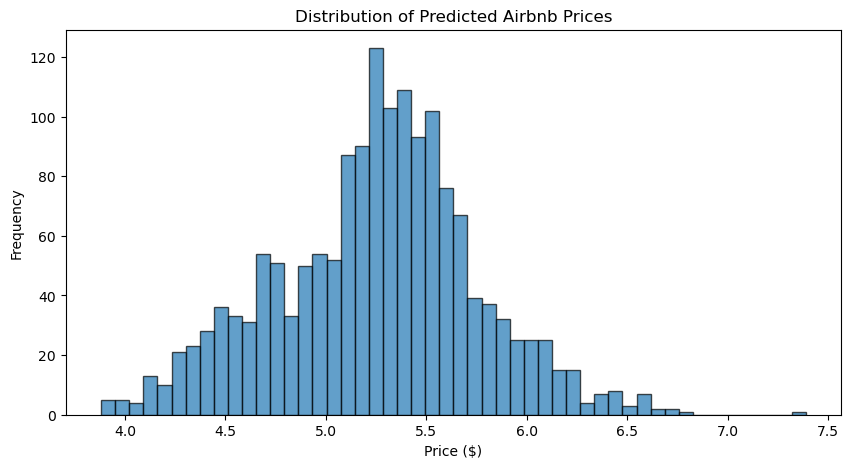

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(y_pred, bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of Predicted Airbnb Prices')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
plt.show()

In [44]:
# changing back to normal price
y_pred_actual = np.expm1(y_pred)

#Creating submission file
submission= pd.DataFrame({
    'ID' : test_imputed['ID'],
    'price' : y_pred_actual
})

submission.to_csv('submission.csv', index = False)


In [45]:
#Downloading submission
from google.colab import files
files.download('submission.csv')

ModuleNotFoundError: No module named 'google.colab'

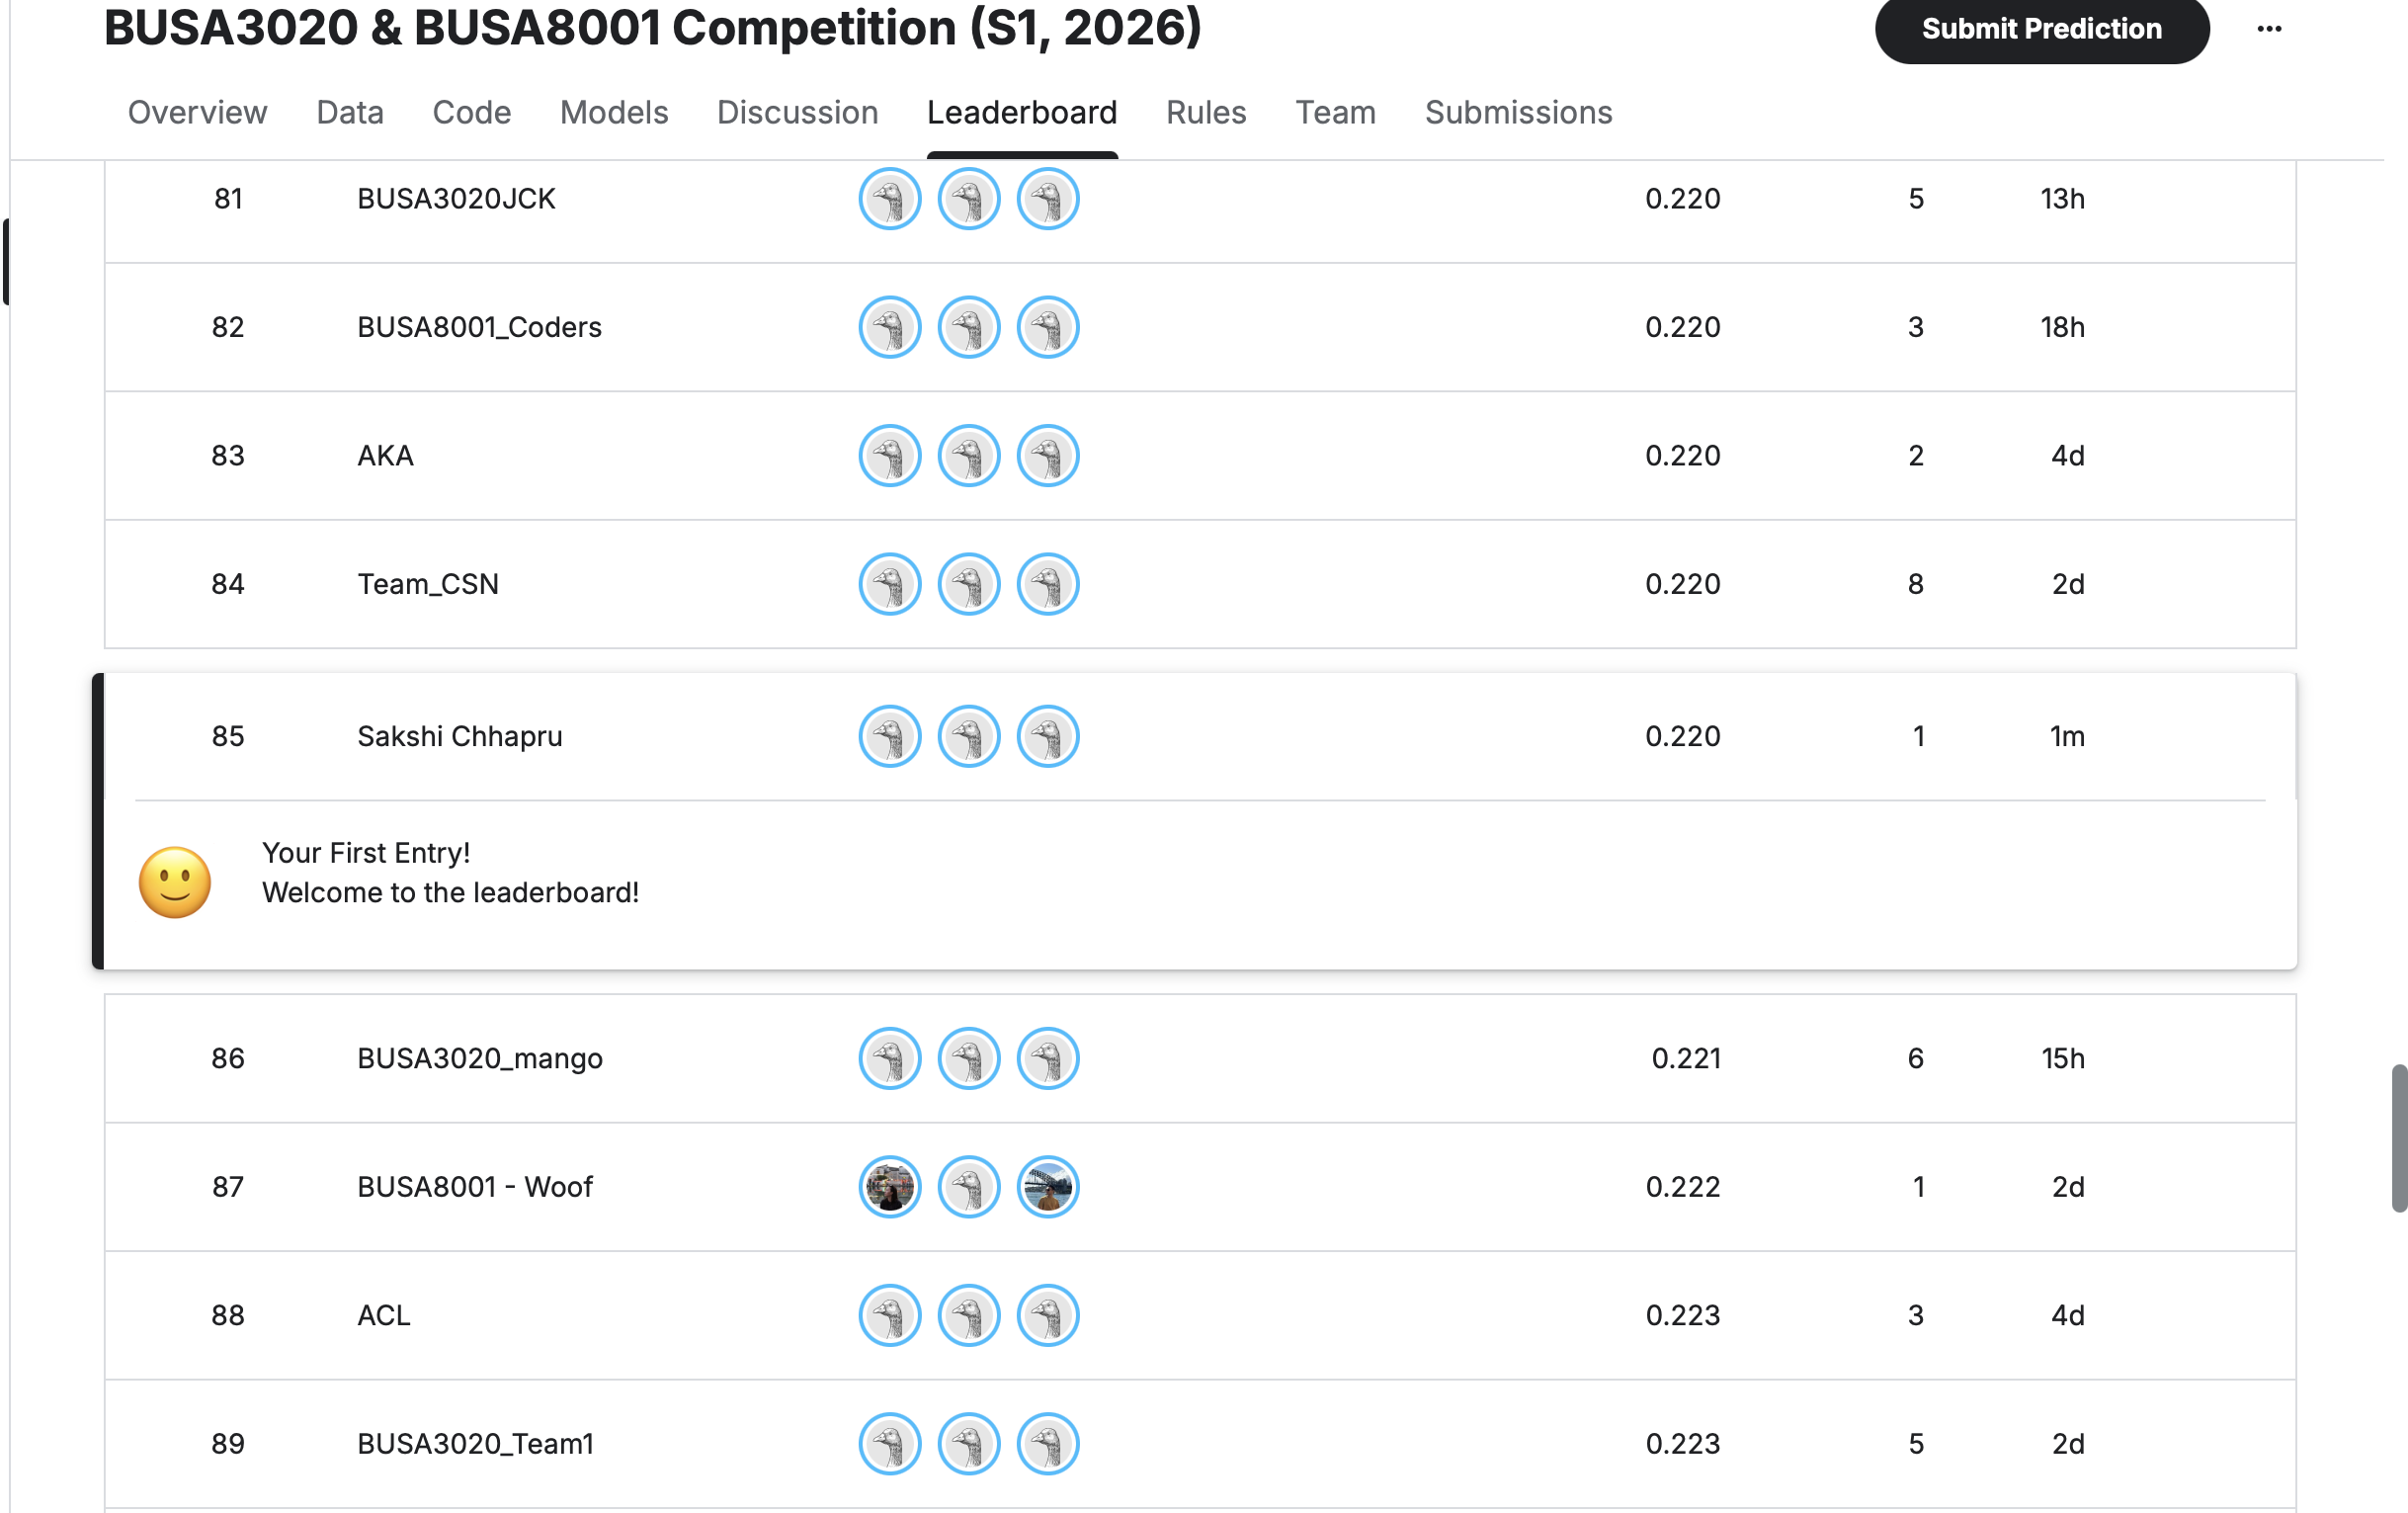

#### Kaggle Score and Ranking

The final Kaggle submission achieved the following results:

| Metric                   | Result |
| ------------------------ | ------ |
| Public Leaderboard Score | 0.220  |
| Leaderboard Ranking      | 85th   |


#### Performance Commentary

The model achieved a public leaderboard MAPE of 0.220 (22.0%), placing 85th out of all competing teams. The cross-validated MAPE of 4.10% was computed on log-transformed prices during model selection, while Kaggle evaluates predictions on the original price scale, so these two figures are not directly comparable. Despite this, the low standard deviation of ±0.14% across the five CV folds indicates consistent model performance regardless of data split, suggesting no significant overfitting occurred. The relatively modest leaderboard ranking suggests room for improvement through broader hyperparameter search or additional feature engineering.

<hr style="width:25%;margin-left:0;">

#### 5. Model Improvement and Reflection (2 marks)

Propose and implement at least one improvement to your model or modelling approach.  
- Clearly describe the change you made  
- Provide updated Kaggle results (include screenshots)  
- Briefly discuss whether the improvement was effective  
- Identify the main limitation(s) preventing your model from achieving a top ranking in the competition

In [ ]:

#  IMPROVED XGBOOST MODEL
model = XGBRegressor(
    # Core settings
    n_estimators=500,              # More trees
    max_depth=5,                   # Limit depth
    learning_rate=0.05,            # Slower learning

    # Sampling
    subsample=0.8,                 # Use 80% of rows per tree
    colsample_bytree=0.8,          # Use 80% of columns per tree

    # Regularization
    reg_alpha=0.1,                 # L1 regularization
    reg_lambda=1.0,                # L2 regularization

    # Objective - MOST IMPORTANT CHANGE
    objective='reg:tweedie',       # Was 'reg:squarederror'
    tweedie_variance_power=1.5,    # For positive skewed targets

    random_state=42,
    n_jobs=1
)


#  TRAIN

print("Training improved XGBoost...")
print(f"Training on {len(y_train)} samples, price range: ${y_train.min():.2f} - ${y_train.max():.2f}")
model.fit(X_train, y_train)


#  PREDICT
y_pred = model.predict(X_test)

# TRANSFORMED BACK
y_pred_og = np.expm1(y_pred)


#  CAP EXTREME PREDICTIONS
y_pred_og = np.clip(y_pred_og, 10, 2000)  # Reasonable Airbnb price range

# CALIBRATION VERSION - 0.99
y_pred_scaled = y_pred_og * 0.99

#  CREATE SUBMISSION

submission2= pd.DataFrame({
    'ID': test_imputed['ID'],
    'price': y_pred_scaled
})

submission2.to_csv('submission2.csv', index=False)

print(f"\nPredictions - Min: ${y_pred_scaled.min():.2f}, Max: ${y_pred_scaled.max():.2f}, Mean: ${y_pred_scaled.mean():.2f}")
print("✅ Submission saved: submission2.csv")

files.download('submission2.csv')

Training improved XGBoost...
Training on 3735 samples, price range: $3.61 - $8.52

Predictions - Min: $51.24, Max: $1462.89, Mean: $212.16
✅ Submission saved: submission2.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

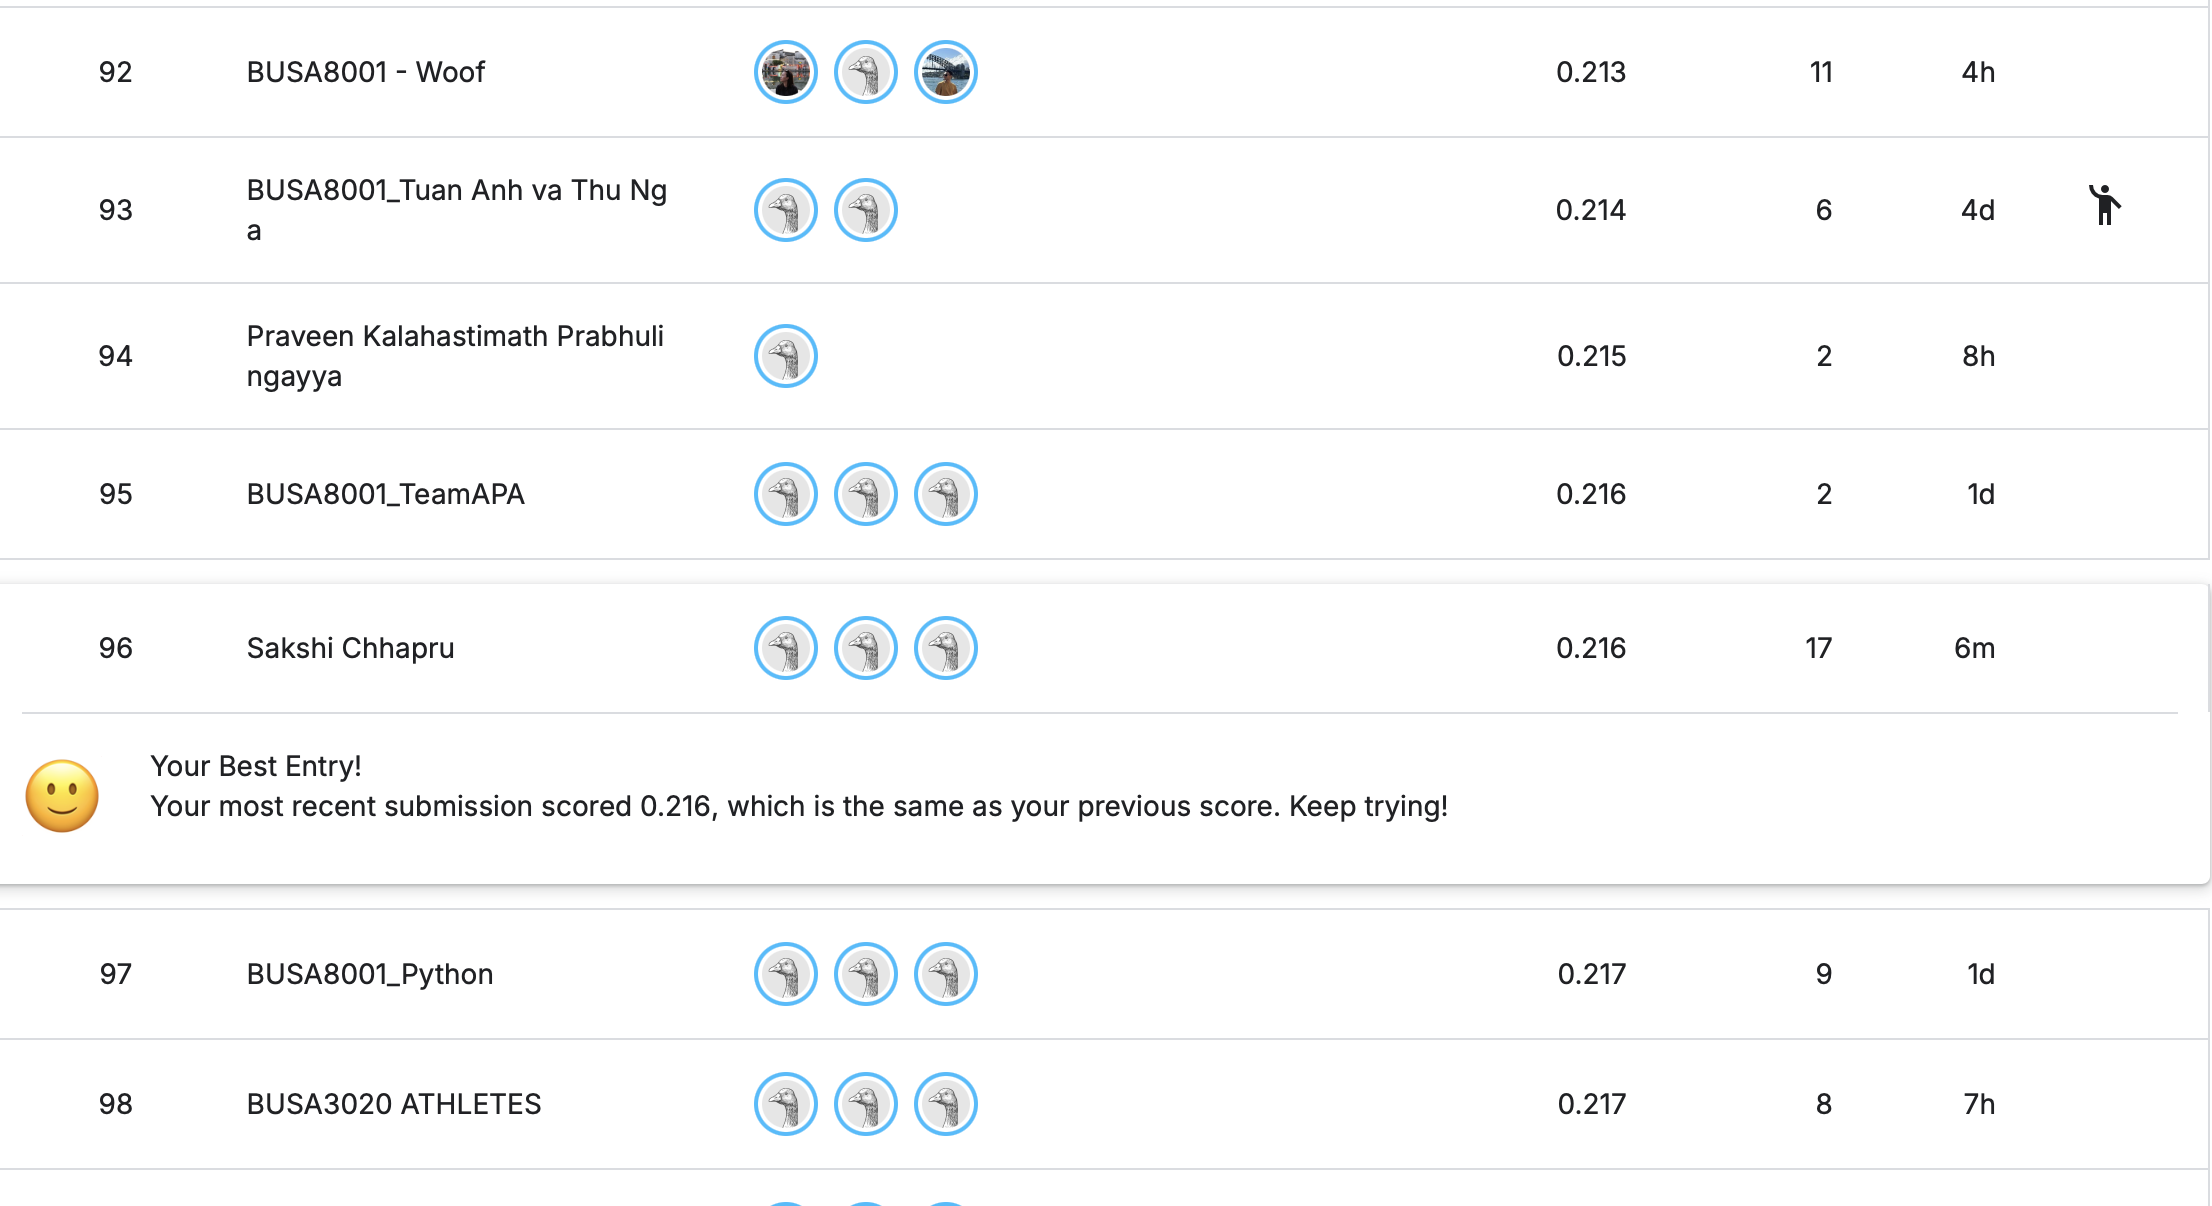---


 Model Improvement and Updated Kaggle Results

To improve the XGBoost model, several changes were made to the modelling approach. The number of trees was increased to 500 so the model could learn more gradually, while the maximum tree depth was reduced to 5 to reduce overfitting. Additional regularisation was also added using `reg_alpha=0.1` and `reg_lambda=1.0`.

The most important change was replacing the `reg:squarederror` objective with `reg:tweedie` using `tweedie_variance_power=1.5`. Since Airbnb prices are positive and heavily right-skewed, the Tweedie objective was better suited to the prediction problem. After prediction, the values were converted back to the original price scale using `np.expm1()`, clipped to a reasonable Airbnb price range.A 0.99 scaling factor was applied as a minor post-processing adjustment. Since the model was trained on log-transformed prices, it was assumed that the inverse transformation via np.expm1() may introduce a slight upward bias in predictions, as the log transformation is not perfectly symmetric. The 0.99 scaling factor was applied as a simple correction to partially account for this.

The updated model achieved a Kaggle public score of **0.216**, improving from the earlier score of **0.220**. Although the leaderboard rank decreased from **85** to **96**, the actual prediction error improved because other teams also submitted stronger models later in the competition.

Overall, the revised model produced a modest but meaningful improvement in leaderboard performance. The Tweedie objective and additional regularisation likely improved the model’s ability to handle the skewed price distribution while reducing excessive model complexity.

The main limitation preventing a higher ranking was likely the available feature set rather than the modelling algorithm itself. While XGBoost captured non-linear relationships effectively, the dataset lacked stronger neighbourhood-level pricing signals, detailed geographic information, and richer amenity interaction variables. External influences such as tourism demand, local events, and seasonal effects were also unavailable. Additionally, the hyperparameter search space was constrained by computational limitations. Expanding the search to include parameters such as min_child_weight, gamma, and colsample_bylevel may have reduced prediction error further, as these parameters directly influence tree complexity, split behaviour, and feature sampling.

---
---
## Marking Criteria

To receive full marks, your solutions must satisfy the following criteria:

- Correct understanding of the problem and adequate use of additional research  
- Analysis follows best practices discussed in lectures and tutorials  
- Use of intuitive and easily understood visualisations and summary statistic tables
- Use of appropriate predictive methods in the context of the given problem  
- Python code is clean, concise, and executes without errors  
- Written explanations are clear, complete, and easy to understand  
- Forecasts are correctly generated and uploaded to Kaggle  
- Results are reproducible from the submitted code  
- The assignment notebook is well-organised and easy to follow  
- Video Presentation:
    - Duration less than 15 minutes
    - Each team member delivers a 5-minute presentation on their assigned task  
    - All assignment questions must be discussed in the video  
    - Your code must be clearly readable in the video  
    - Discuss both the actions you took and, more importantly, the reasoning behind these actions, explaining the significance of key steps  
    - Ensure that both your face and Jupyter Notebook are clearly visible during the recording
- Failure to meet the above criteria will result in a deduction of marks  


---
---